In [26]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(r"D:\python\Packages")
    
import os
import optuna
import pickle
import subprocess
import pandas as pd
import numpy as np
import xgboost as xgb
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error

import random
# ====================================================================
# 0. 环境和初始准备
# ================================== ===================================

RANDOM_SEED = 120

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

file_path = r'D:\RUC\B1WTA_new\TEST\energy_wta_with_post_weights.csv'
output_dir = r'D:\RUC\B1WTA_new\TEST\empirical4.2_result'

df = pd.read_csv(file_path)

# ====================================================================
# 1. 函数准备
# =====================================================================

# ------------------------------ 数据处理 ------------------------------
def get_subset_data(data, mode="car"):
    """
    根据模式提取对应的子集
    """
    if mode == "car":
        return data[data['publictrans'] < 5].copy()
    elif mode == "elec":
        return data[data['conditionernumber'] == 1].copy()
    elif mode == "green":
        return data[data['energy_consume2020'] > 1000].copy()
    else:
        raise ValueError("模式错误，请选择 'car', 'elec' 或 'green'")
        
# ------------------------------ 模型训练 ------------------------------
# Y MODEL
def train_xgb_model_bayesian(train_x, train_y, group_type="All", n_trials=50, cv=2):
    """
    group_type: "All" 使用当前参数空间, "Demos" 使用另一套参数空间
    """
    
    def objective(trial):
        if group_type == "All":
            # --- 参数空间 (All 组) ---
            param = {
                "n_estimators": trial.suggest_int("n_estimators", 20, 200, step=10),
                "max_depth": trial.suggest_int("max_depth", 2, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2),
                "lambda": trial.suggest_float("reg_lambda", 0.8, 2.6),
                "gamma": trial.suggest_float("gamma", 1.3, 3.6),
            }
            
        else:
            # --- 参数空间 (Demos 组) ---
            param = {
                "n_estimators": trial.suggest_int("n_estimators", 20, 200, step=10),
                "max_depth": trial.suggest_int("max_depth", 2, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2),
                "lambda": trial.suggest_float("reg_lambda", 0.8, 2.6),
                "gamma": trial.suggest_float("gamma", 1.3, 3.6),
            }

            
        # 公共固定参数
        param.update({
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": RANDOM_SEED,
            "n_jobs": -1
        })
        
        model = xgb.XGBClassifier(**param)
        score = cross_val_score(model, train_x, train_y, cv=cv, scoring='accuracy').mean()
        return score

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    print(f"正在进行 [{group_type}] 组贝叶斯优化...")
    study.optimize(objective, n_trials=n_trials)
    
    final_params = study.best_params.copy()
    final_params.update({"objective": "binary:logistic", "eval_metric": "logloss", "random_state": RANDOM_SEED})
    
    best_model = xgb.XGBClassifier(**final_params)
    best_model.fit(train_x, train_y)
    
    return best_model

# WTA MODEL
def train_xgb_regressor_bayesian(train_x, train_y, group_type="All", n_trials=50, cv=3):
    def objective(trial):
        param = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 490, step=20),
            "max_depth": trial.suggest_int("max_depth", 3, 7),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
            "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),
            "gamma": trial.suggest_float("gamma", 0, 2.0),
            "objective": "reg:squarederror", # 切换为回归损失函数
            "random_state": RANDOM_SEED,
            "n_jobs": -1
        }
        model = xgb.XGBRegressor(**param)
        # 回归模型通常使用负均方误差（越高越好）
        score = cross_val_score(model, train_x, train_y, cv=cv, scoring='neg_mean_squared_error').mean()
        return score

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)
    
    best_model = xgb.XGBRegressor(**study.best_params, random_state=RANDOM_SEED)
    best_model.fit(train_x, train_y)
    return best_model
    
# ------------------------------ 决策表格 ------------------------------
# 获取概率流程 
def get_group_probabilities(model_dict, test_df, group_suffix="Demos"):
    prob_df = pd.DataFrame(index=test_df.index)
    for sub in ['Car', 'Elec', 'Green']:
        m_name = f"{sub}_{group_suffix}"
        if m_name in model_dict:
            model = model_dict[m_name]
            # 自动获取特征列名并预测
            feats = model.get_booster().feature_names
            prob_df[f'prob_{sub.lower()}'] = model.predict_proba(test_df[feats])[:, 1]
    return prob_df

# 得到表格流程（决策+评估+清洗集成）
def get_processed_results(prob_df, test_df, threshold=0.5):
    """
    将决策、评估、清洗逻辑向量化，一步到位生成结果表
    """
    res = prob_df.copy()
    
    # --- A. 约束决策逻辑 (向量化处理) ---
    # 定义准入掩码：不符合条件的设为 True
    mask_car = test_df['publictrans'] >= 5
    mask_elec = test_df['conditionernumber'] != 1
    mask_green = test_df['energy_consume2020'] <= 1000
    
    # 强制抹除不合规概率
    if 'prob_car' in res: res.loc[mask_car, 'prob_car'] = -1.0
    if 'prob_elec' in res: res.loc[mask_elec, 'prob_elec'] = -1.0
    if 'prob_green' in res: res.loc[mask_green, 'prob_green'] = -1.0
    
    prob_cols = [c for c in res.columns if c.startswith('prob_')]
    res['max_probability'] = res[prob_cols].max(axis=1)
    res['best_option'] = res[prob_cols].idxmax(axis=1).str.replace('prob_', '').str.capitalize()
    
    # --- B. 阈值清洗 & 无效处理 ---
    # 只要最大概率不达标，或者原本就没合规选项的，统一设为 None
    invalid_mask = (res['max_probability'] <= threshold) | (res['max_probability'] == -1.0)
    res.loc[invalid_mask, 'best_option'] = 'None'
    
    # --- C. 评估逻辑 (向量化匹配) ---
    res['is_valid'] = (~invalid_mask).astype(int)
    res['real_wta_val'] = np.nan
    res['is_accept'] = 0
    res['is_perfect'] = 0
    
    # 针对每种选择，一次性匹配所有样本的 WTA 和 Label
    for opt in ['car', 'elec', 'green']:
        opt_mask = (res['best_option'].str.lower() == opt)
        if opt_mask.any():
            # 填充真实值
            res.loc[opt_mask, 'real_wta_val'] = test_df.loc[opt_mask, f'wta_{opt}']
            real_y = test_df.loc[opt_mask, f'y_{opt}']
            
            # 计算 Accept 和 Perfect
            res.loc[opt_mask, 'is_accept'] = (res.loc[opt_mask, 'real_wta_val'] > 1).astype(int)
            res.loc[opt_mask, 'is_perfect'] = ((res.loc[opt_mask, 'is_accept'] == 1) & (real_y == 1)).astype(int)

    return res[['best_option', 'max_probability'] + prob_cols + 
               ['is_valid', 'real_wta_val', 'is_accept', 'is_perfect']]

# 计算指标
def calculate_metrics(demos_df, all_df):
    """
    计算性能对比表，新增 Accept_Cost (平均接受成本)
    """
    # 定义映射字典
    cost_map = {7: 0, 6: 10, 5: 25, 4: 50, 3: 75, 2: 100}
    
    res = []
    for name, df in [("Demos 组", demos_df), ("All 组", all_df)]:
        # 1. 筛选有效预测
        valid_samples = df[df['is_valid'] == 1].copy()
        n_total = len(df)
        n_valid = len(valid_samples)
        
        # 2. 基础率计算
        accept_rate = valid_samples['is_accept'].mean() if n_valid > 0 else 0
        perfect_rate = valid_samples['is_perfect'].mean() if n_valid > 0 else 0
        
        # 3. 计算 Accept_Cost
        # 思路：仅在 is_accept == 1 的样本中，将 real_wta_val 映射为金额，然后求均值
        accepted_samples = valid_samples[valid_samples['is_accept'] == 1]
        if len(accepted_samples) > 0:
            # 映射并计算平均值
            accept_cost = accepted_samples['real_wta_val'].map(cost_map).mean()
        else:
            accept_cost = 0
        
        res.append({
            "Group": name,
            "Total_Tests": n_total,
            "Valid_Predictions": n_valid,
            "Validity_Rate": n_valid / n_total,
            "Accept_Rate": accept_rate,
            "Perfect_Rate": perfect_rate,
            "Accept_Cost": accept_cost  # 新增字段
        })
    
    return pd.DataFrame(res).set_index("Group")

# ideal情景df生成
def get_ideal_results(test_df):
    """
    模拟理想情况：受访者总是选择其真实 y=1 的有效选项
    """
    res = pd.DataFrame(index=test_df.index)
    
    # 1. 映射真实标签
    res['best_option'] = 'None'
    for opt in ['car', 'elec', 'green']:
        res.loc[test_df[f'y_{opt}'] == 1, 'best_option'] = opt.capitalize()
    
    # 2. 提取对应的真实 WTA
    res['real_wta_val'] = np.nan
    for opt in ['car', 'elec', 'green']:
        mask = (res['best_option'] == opt.capitalize())
        res.loc[mask, 'real_wta_val'] = test_df.loc[mask, f'wta_{opt}']
    
    # 3. 理想情况下的指标
    res['is_valid'] = (res['best_option'] != 'None').astype(int)
    res['is_accept'] = res['is_valid']
    res['is_perfect'] = res['is_valid']
    res['max_probability'] = 1.0  
    
    return res

# xgb和eco情景df生成
def get_processed_results(probs_df, test_df, threshold=0.5):
    """
    统一处理逻辑：将概率转化为决策，并计算 is_valid, is_accept, is_perfect
    """
    res = probs_df.copy()
    
    # 1. 找出概率最大的选项及其概率
    res['max_probability'] = res[['prob_car', 'prob_elec', 'prob_green']].max(axis=1)
    res['best_option'] = res[['prob_car', 'prob_elec', 'prob_green']].idxmax(axis=1).str.replace('prob_', '')
    
    # 2. 准入条件过滤 (基于 test_df 的原始数据)
    # 必须满足子集准入条件，且最大概率 > 阈值，才视为有效预测 (is_valid=1)
    mask_car = (res['best_option'] == 'car') & (test_df['publictrans'] < 5)
    mask_elec = (res['best_option'] == 'elec') & (test_df['conditionernumber'] == 1)
    mask_green = (res['best_option'] == 'green') & (test_df['energy_consume2020'] > 1000)
    
    res['is_valid'] = ((mask_car | mask_elec | mask_green) & (res['max_probability'] > threshold)).astype(int)
    
    # 3. 结果判定
    # 提取选定选项的真实 WTA
    res['real_wta_val'] = np.nan
    for opt in ['car', 'elec', 'green']:
        mask = (res['best_option'] == opt)
        res.loc[mask, 'real_wta_val'] = test_df.loc[mask, f'wta_{opt}']
    
    # 是否被接受 (真实 WTA > 1)
    res['is_accept'] = ((res['is_valid'] == 1) & (res['real_wta_val'] > 1)).astype(int)
    
    # 是否完美匹配 (真实 y_... == 1)
    res['is_perfect'] = 0
    for opt in ['car', 'elec', 'green']:
        mask = (res['best_option'] == opt) & (res['is_valid'] == 1)
        res.loc[mask, 'is_perfect'] = test_df.loc[mask, f'y_{opt}']
        
    return res

# random情景df生成
def run_monte_carlo_random(test_df, n_iterations=200):
    """
    执行 n 次随机模拟，并计算各项指标的平均值
    """
    all_metrics = []
    
    # 定义成本映射（确保与你的 calculate_metrics 函数一致）
    cost_map = {7: 0, 6: 10, 5: 25, 4: 50, 3: 75, 2: 100}
    
    # 提前识别合规选项池，避免循环内重复计算
    can_car = (test_df['publictrans'] < 5)
    can_elec = (test_df['conditionernumber'] == 1)
    can_green = (test_df['energy_consume2020'] > 1000)

    for i in range(n_iterations):
        # 每次迭代使用不同的随机种子，但过程可追溯
        np.random.seed(RANDOM_SEED + i)
        
        # 1. 快速生成本轮随机决策
        res = pd.DataFrame(index=test_df.index)
        res['best_option'] = 'None'
        
        # 优化随机逻辑：向量化生成合规列表
        for idx in test_df.index:
            available = []
            if can_car.loc[idx]: available.append('car')
            if can_elec.loc[idx]: available.append('elec')
            if can_green.loc[idx]: available.append('green')
            
            if available:
                res.loc[idx, 'best_option'] = np.random.choice(available)
        
        # 2. 评估本轮表现
        res['is_valid'] = (res['best_option'] != 'None').astype(int)
        valid_df = res[res['is_valid'] == 1].copy()
        
        if len(valid_df) > 0:
            # 匹配真实 WTA 和 Perfect 标签
            res['real_wta_val'] = np.nan
            res['is_perfect'] = 0
            for opt in ['car', 'elec', 'green']:
                mask = (res['best_option'] == opt)
                if mask.any():
                    res.loc[mask, 'real_wta_val'] = test_df.loc[mask, f'wta_{opt}']
                    res.loc[mask, 'is_perfect'] = (test_df.loc[mask, f'y_{opt}'] == 1).astype(int)
            
            # 计算本轮指标
            accept_mask = (res['is_valid'] == 1) & (res['real_wta_val'] > 1)
            is_accept_all = accept_mask.astype(int)
            
            # 本轮汇总
            n_valid = len(valid_df)
            round_accept_rate = is_accept_all.sum() / n_valid
            round_perfect_rate = (res['is_perfect']).sum() / n_valid
            
            # 成本计算
            accepted_wta = res.loc[accept_mask == 1, 'real_wta_val']
            round_cost = accepted_wta.map(cost_map).mean() if len(accepted_wta) > 0 else 0
            
            all_metrics.append({
                "Validity_Rate": n_valid / len(test_df),
                "Accept_Rate": round_accept_rate,
                "Perfect_Rate": round_perfect_rate,
                "Accept_Cost": round_cost
            })

    # 3. 取 200 次试验的平均值
    avg_results = pd.DataFrame(all_metrics).mean()
    
    # 转换为与 calculate_metrics 输出一致的格式
    final_random_df = pd.DataFrame([ {
        "Group": "Random (Lower Bound)",
        "Total_Tests": len(test_df),
        "Valid_Predictions": int(avg_results['Validity_Rate'] * len(test_df)),
        "Validity_Rate": avg_results['Validity_Rate'],
        "Accept_Rate": avg_results['Accept_Rate'],
        "Perfect_Rate": avg_results['Perfect_Rate'],
        "Accept_Cost": avg_results['Accept_Cost']
    } ]).set_index("Group")
    
    return final_random_df

# 表格输出格式
format_dict = {
    'Validity_Rate': '{:.2%}',
    'Accept_Rate': '{:.2%}',
    'Perfect_Rate': '{:.2%}',
    'Accept_Cost': '{:.2f} 元'
}

# 4.2.2/4.2.3：XGB加入对应的、pred的wta
def append_final_wta_column(results_df, test_df, xgb_reg_dict, group_suffix="All"):
    """
    根据分类模型的 best_option，提取对应回归模型的预测 WTA 值并取整
    """
    df = results_df.copy()
    
    # 1. 临时存储三个选项的回归预测值
    temp_cols = []
    for opt in ['car', 'elec', 'green']:
        m_key = f"{opt.capitalize()}_{group_suffix}_Reg"
        col_name = f'temp_pred_{opt}'
        
        if m_key in xgb_reg_dict:
            model = xgb_reg_dict[m_key]
            feats = model.get_booster().feature_names
            # 预测并立即向下取整
            df[col_name] = np.floor(model.predict(test_df[feats])).astype(int)
            temp_cols.append(col_name)

    # 2. 核心逻辑：根据 best_option 的值，从对应的 temp 列里“点菜”
    # 初始化最终列
    df['pred_wta_val'] = np.nan
    
    for opt in ['car', 'elec', 'green']:
        # 匹配条件：分类选了这一项，且该项有回归预测值
        mask = (df['best_option'].str.lower() == opt)
        temp_col = f'temp_pred_{opt}'
        if temp_col in df.columns:
            df.loc[mask, 'pred_wta_val'] = df.loc[mask, temp_col]

    # 3. 清理：删除临时的中间预测列，保持 DataFrame 简洁
    df.drop(columns=temp_cols, inplace=True)
    
    return df

# 4.2.2/4.2.3：ECO加入对应的、pred的wta
def update_eco_results_with_floor(results_df, preds_path):
    """
    results_df: 之前生成的包含 best_option 和 is_valid 的表格
    preds_path: R 导出的 wta_preds_all.csv 或 demos.csv 路径
    """
# 读取 R 导出的连续分值
    preds_raw = pd.read_csv(preds_path)
    preds_raw.index = test_data.index
    
    # 建立选项到列名的映射 (确保涵盖可能出现的各种拼写)
    opt_map = {
        'Car': 'pred_wta_car', 'car': 'pred_wta_car',
        'Elec': 'pred_wta_elec', 'elec': 'pred_wta_elec',
        'Green': 'pred_wta_green', 'green': 'pred_wta_green'
    }
    
    # 动态提取预测分值
    for idx in results_df.index:
        # 只处理有效的行，且确保 best_option 不为空
        best_opt = results_df.loc[idx, 'best_option']
        
        if results_df.loc[idx, 'is_valid'] == 1 and pd.notna(best_opt):
            col_name = opt_map.get(best_opt)
            
            if col_name is not None:
                # 安全提取 R 导出的连续分值
                raw_val = preds_raw.loc[idx, col_name]
                # 执行向下取整
                results_df.loc[idx, 'pred_wta_val'] = np.floor(raw_val)
            else:
                # 如果 best_option 不在映射里，打印提示以便排查
                # print(f"⚠️ 索引 {idx} 的选项 '{best_opt}' 无法识别")
                results_df.loc[idx, 'pred_wta_val'] = np.nan
        else:
            results_df.loc[idx, 'pred_wta_val'] = np.nan
            
    return results_df

# ------------------------------ EMPIRICAL 4.2.2 ------------------------------
    
# 7.1 指标计算函数（保持不变，但在调用时逻辑更清晰）
def get_n_household_metrics(results_df, test_df, n_list=[50, 100, 150], sort=True):
    cost_map = {7: 0, 6: 10, 5: 25, 4: 50, 3: 75, 2: 100, 1: 0}
    eval_pool = results_df[results_df['is_valid'] == 1].copy()
    
    # 匹配真实 WTA
    eval_pool['real_wta_code'] = np.nan
    for opt in ['car', 'elec', 'green']:
        mask = (eval_pool['best_option'].str.lower() == opt)
        if mask.any():
            target_indices = eval_pool[mask].index
            eval_pool.loc[mask, 'real_wta_code'] = test_df.loc[target_indices, f'wta_{opt}']
    
    # 排序逻辑：模型组排序，Random组在传入前已打乱，此处不重复排序
    if sort:
        sort_cols = []
        if 'pred_wta_val' in eval_pool.columns: sort_cols.append('pred_wta_val')
        elif 'real_wta_val' in eval_pool.columns: sort_cols.append('real_wta_val')
        if 'max_probability' in eval_pool.columns: sort_cols.append('max_probability')
        if sort_cols:
            eval_pool = eval_pool.sort_values(by=sort_cols, ascending=False)
            
    summary_rows = []
    for n in n_list:
        if len(eval_pool) >= n:
            winners = eval_pool.head(n)
            valid_winners = winners.dropna(subset=['real_wta_code'])
            accepted_winners = valid_winners[valid_winners['real_wta_code'] > 1]
            accept_count = len(accepted_winners)
            
            summary_rows.append({
                "Quota (N)": n,
                "Accept_Rate": accept_count / n,
                "Accept_Cost": accepted_winners['real_wta_code'].map(cost_map).mean() if accept_count > 0 else 0.0
            })
        else:
            summary_rows.append({"Quota (N)": n, "Accept_Rate": np.nan, "Accept_Cost": np.nan})
    return pd.DataFrame(summary_rows)

# 7.2 蒙特卡罗模拟：计算 1000 次随机的平均值
def get_random_baseline_monte_carlo(test_df, n_list, iterations=1000):
    print(f"🔄 正在进行 {iterations} 次蒙特卡洛随机模拟...")
    all_sim_results = []
    
    for i in range(iterations):
        # 1. 随机决策
        random_results = []
        for idx, row in test_df.iterrows():
            eligible = []
            if row['publictrans'] < 5: eligible.append('Car')
            if row['conditionernumber'] == 1: eligible.append('Elec')
            if row['energy_consume2020'] > 1000: eligible.append('Green')
            
            if not eligible:
                random_results.append({'best_option': 'None', 'is_valid': 0})
            else:
                # 随机选一个项目
                random_results.append({'best_option': np.random.choice(eligible), 'is_valid': 1})
        
        df_sim = pd.DataFrame(random_results, index=test_df.index)
        
        # 2. 计算该次随机下的指标 (注意 sort=False，模拟自然随机状态)
        # 我们不使用 seed，让每次循环都不同
        metrics = get_n_household_metrics(df_sim, test_df, n_list=n_list, sort=False)
        all_sim_results.append(metrics)
    
    # 3. 对 1000 次结果取均值
    combined_sim = pd.concat(all_sim_results)
    mean_random_metrics = combined_sim.groupby("Quota (N)").mean().reset_index()
    return mean_random_metrics

# ------------------------------ EMPIRICAL 4.2.3 ------------------------------
# --- 预算指标计算函数  ---
def get_budget_metrics(results_df, test_df, budget_list=[1000, 2000, 3000, 4000], sort=True):
    cost_map = {7: 0, 6: 10, 5: 25, 4: 50, 3: 75, 2: 100, 1: 0}
    eval_pool = results_df[results_df['is_valid'] == 1].copy()
    eval_pool['real_wta_code'] = np.nan
    for opt in ['car', 'elec', 'green']:
        mask = (eval_pool['best_option'].str.lower() == opt)
        if mask.any():
            target_indices = eval_pool[mask].index
            eval_pool.loc[mask, 'real_wta_code'] = test_df.loc[target_indices, f'wta_{opt}']
    
    eval_pool['individual_cost'] = eval_pool['real_wta_code'].map(cost_map)
    
    if sort:
        sort_cols = []
        if 'pred_wta_val' in eval_pool.columns: sort_cols.append('pred_wta_val')
        elif 'real_wta_val' in eval_pool.columns: sort_cols.append('real_wta_val')
        if 'max_probability' in eval_pool.columns: sort_cols.append('max_probability')
        if sort_cols:
            eval_pool = eval_pool.sort_values(by=sort_cols, ascending=False)
    
    budget_summary = []
    for limit in budget_list:
        eval_pool['cum_cost'] = eval_pool['individual_cost'].cumsum()
        winners = eval_pool[eval_pool['cum_cost'] <= limit]
        n_recruited = len(winners)
        if n_recruited > 0:
            accepted_winners = winners[winners['real_wta_code'] > 1]
            accept_rate = len(accepted_winners) / n_recruited
        else:
            accept_rate = 0.0
        budget_summary.append({
            "Budget_Limit": limit,
            "Total_Recruited (N)": n_recruited,
            "Accept_Rate": accept_rate
        })
    return pd.DataFrame(budget_summary)

# --- 蒙特卡洛随机模拟 (预算版) ---
def get_random_budget_baseline_monte_carlo(test_df, budget_list, iterations=1000):
    print(f"🔄 正在进行 {iterations} 次预算约束下的蒙特卡洛随机模拟...")
    all_sim_results = []
    
    for i in range(iterations):
        # 1. 随机决策逻辑 (与 4.2.2 保持完全一致)
        random_results = []
        for idx, row in test_df.iterrows():
            eligible = []
            if row['publictrans'] < 5: eligible.append('Car')
            if row['conditionernumber'] == 1: eligible.append('Elec')
            if row['energy_consume2020'] > 1000: eligible.append('Green')
            
            if not eligible:
                random_results.append({'best_option': 'None', 'is_valid': 0})
            else:
                # 模拟完全随机挑选一个符合条件的补贴项目
                random_results.append({
                    'best_option': np.random.choice(eligible), 
                    'is_valid': 1
                })
        
        df_sim = pd.DataFrame(random_results, index=test_df.index)
        
        # 2. 计算该次随机下的预算指标 
        # 注意：sort=False 非常重要！代表随机发放补贴，不按任何预测值排序
        metrics = get_budget_metrics(df_sim, test_df, budget_list=budget_list, sort=False)
        all_sim_results.append(metrics)
    
    # 3. 对 1000 次结果取均值进行归并
    combined_sim = pd.concat(all_sim_results)
    mean_random_metrics = combined_sim.groupby("Budget_Limit").mean().reset_index()
    
    return mean_random_metrics

# ------------------------------ Empirical 4.3 ------------------------------
def simulate_policy_knowledge_upgrade(df):
    sim_df = df.copy()
    
    # ---------------------------------------------------------
    # 步骤 1: 连续化处理 (De-discretization)
    # 将 1-7 的整数级转为 [level, level+1) 的浮点数
    # ---------------------------------------------------------
    wta_cols = ['wta_car', 'wta_elec', 'wta_green']
    for col in wta_cols:
        # 只针对非 7 级（未封顶）的样本进行扰动，增加模拟的连续性
        mask_not_max = (sim_df[col] < 7) & (sim_df[col] >= 1)
        sim_df.loc[mask_not_max, col] = sim_df.loc[mask_not_max, col] + np.random.uniform(0, 1, size=mask_not_max.sum())

    # 基于4.1结果重新校准的参数 (Mean, SE)
    params = {
        'wta_car':   {'heard_not_know': (0.183, 0.186), 'heard_know': (0.697, 0.366)},
        'wta_elec':  {'heard_not_know': (0.641, 0.208), 'heard_know': (0.888, 0.363)},
        'wta_green': {'heard_not_know': (0.357, 0.159), 'heard_know': (0.972, 0.286)}
    }

    policy_col = 'know_about_carbon_policy'
    mask_never = (sim_df[policy_col] == 'never')
    mask_not_know = (sim_df[policy_col] == 'heard but do not know')
    
    # ---------------------------------------------------------
    # 步骤 2: 应用因果干预 (Causal Intervention)
    # ---------------------------------------------------------
    for target_wta in wta_cols:
        m_k, se_k = params[target_wta]['heard_know']
        m_n, se_n = params[target_wta]['heard_not_know']
        
        # A. 'never' -> 'heard and know'
        if mask_never.any():
            delta_never = np.random.normal(m_k, se_k, size=mask_never.sum())
            # 认知提升通常增加补偿预期，np.maximum 确保方向正确
            sim_df.loc[mask_never, target_wta] += np.maximum(delta_never, 0)
            
        # B. 'heard but do not know' -> 'heard and know'
        if mask_not_know.any():
            size = mask_not_know.sum()
            rand_know = np.random.normal(m_k, se_k, size=size)
            rand_not_know = np.random.normal(m_n, se_n, size=size)
            delta_diff = rand_know - rand_not_know
            sim_df.loc[mask_not_know, target_wta] += np.maximum(delta_diff, 0)

        # ---------------------------------------------------------
        # 步骤 3: 还原离散化并限制范围 (Re-discretization)
        # ---------------------------------------------------------
        # 向下取整回归 1-7 级
        sim_df[target_wta] = np.floor(sim_df[target_wta]).clip(lower=1, upper=7)

    # ---------------------------------------------------------
    # 步骤 4: 更新认知标签与决策逻辑
    # ---------------------------------------------------------
    affected_mask = mask_never | mask_not_know
    sim_df.loc[affected_mask, policy_col] = 'heard and know'
    
    # 重新计算决策标签 y (基于新的 WTA)
    sim_df['max_wta'] = sim_df[wta_cols].max(axis=1)
    for wta_col, y_col in zip(wta_cols, ['y_car', 'y_elec', 'y_green']):
        # 规则：选择 WTA 最大的项，且 WTA 必须大于 1 (即不选“完全不需要补偿”)
        sim_df[y_col] = ((sim_df[wta_col] == sim_df['max_wta']) & (sim_df['max_wta'] > 1)).astype(int)
    
    return sim_df

# ------------------------------ 绘画用函数 ------------------------------
def clean_pct(val):
    if isinstance(val, str):
        clean = val.replace('%', '').replace('元', '').replace(',', '').strip()
        return float(clean)
    return float(val)
    
def append_metrics(target_dict, df, row_idx):
        if 'accept_cost' not in target_dict:
            target_dict['accept_cost'] = []
            target_dict['accept_rate'] = []
        target_dict['accept_cost'].append(df.iloc[row_idx]['Accept_Cost'])
        target_dict['accept_rate'].append(df.iloc[row_idx]['Accept_Rate'])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#pip list
import pandas, pickle, shutil, subprocess, scipy, numpy, sklearn, xgboost, optuna, matplotlib, tqdm
for lib in [pandas, scipy, numpy, sklearn, xgboost, optuna, matplotlib, tqdm]:
    print(f"{lib.__name__}=={lib.__version__}")

pandas==2.0.0
scipy==1.10.1
numpy==1.23.5
sklearn==1.6.1
xgboost==3.1.2
optuna==4.7.0
matplotlib==3.8.2
tqdm==4.65.0


原数据中比例   | y_car: 0.6922 | y_elec: 0.6529 | y_green: 0.4612
训练集中比例   | y_car: 0.6918 | y_elec: 0.6521 | y_green: 0.4616
测试集中比例   | y_car: 0.6933 | y_elec: 0.6550 | y_green: 0.4601
✅ 数据已成功输出至: D:\RUC\B1WTA_new\TEST\empirical4.2_result
训练集样本量: 730 | 测试集样本量: 313

==================== XGBoost 训练任务初始化 ====================
✅ 核心数据集准备完毕：
   - Car   子集: 训练集 460 行, 测试集 206 行
   - Elec  子集: 训练集 337 行, 测试集 136 行
   - Green 子集: 训练集 635 行, 测试集 270 行

📊 模型方案:
子集         | 因变量        | demos特征数     | demos_all特征数   
------------------------------------------------------------
Car        | y_car         | 32              | 47             
Elec       | y_elec        | 32              | 47             
Green      | y_green       | 32              | 47             

🚀 总体任务：基于上述 3 个子集 × 2 套特征方案，共计训练 6 个 XGBoost 模型。



In [2]:
# ====================================================================
# 2. 数据处理
# ====================================================================

# (1) 创造新变量 y
wta_cols = ['wta_car', 'wta_elec', 'wta_green']
y_cols = ['y_car', 'y_elec', 'y_green']
df['max_wta'] = df[wta_cols].max(axis=1)

for wta_col, y_col in zip(wta_cols, y_cols):
    df[y_col] = ((df[wta_col] == df['max_wta']) & (df['max_wta'] > 1)).astype(int)

# (2) 划分训练集、测试集
df['stratify_key'] = df['y_car'].astype(str) + df['y_elec'].astype(str) + df['y_green'].astype(str)

train_data, test_data = train_test_split(
    df, 
    test_size=0.3, 
    random_state=RANDOM_SEED,
    stratify=df['stratify_key']  # 按照组合比例划分
)

train_data = train_data.drop(columns=['stratify_key'])
test_data = test_data.drop(columns=['stratify_key'])

print(f"原数据中比例   | y_car: {df['y_car'].mean():.4f} | y_elec: {df['y_elec'].mean():.4f} | y_green: {df['y_green'].mean():.4f}")
print(f"训练集中比例   | y_car: {train_data['y_car'].mean():.4f} | y_elec: {train_data['y_elec'].mean():.4f} | y_green: {train_data['y_green'].mean():.4f}")
print(f"测试集中比例   | y_car: {test_data['y_car'].mean():.4f} | y_elec: {test_data['y_elec'].mean():.4f} | y_green: {test_data['y_green'].mean():.4f}")

train_data.to_csv(os.path.join(output_dir, 'train_data.csv'), index=False, encoding='utf-8-sig')
test_data.to_csv(os.path.join(output_dir, 'test_data.csv'), index=False, encoding='utf-8-sig')
test_data_eco = test_data.copy()

print(f"✅ 数据已成功输出至: {output_dir}")
print(f"训练集样本量: {len(train_data)} | 测试集样本量: {len(test_data)}")

# (3) XGBOOST适应数据准备：One-Hot Encode
categorical_cols = [
    'location', 'province', 'weekday', 
    'heard_about_global_warming', 'know_about_low_carbon', 
    'know_about_carbon_neutrality', 'know_about_carbon_policy'
]

train_data = pd.get_dummies(train_data, columns=categorical_cols, drop_first=False)
test_data = pd.get_dummies(test_data, columns=categorical_cols, drop_first=False)

train_data = train_data.astype(int, errors='ignore')
test_data = test_data.astype(int, errors='ignore')

# (4) XGBOOST适应数据准备：Subset
        
train_car = get_subset_data(train_data, mode="car")
train_elec = get_subset_data(train_data, mode="elec")
train_green = get_subset_data(train_data, mode="green")

test_car = get_subset_data(test_data, mode="car")
test_elec = get_subset_data(test_data, mode="elec")
test_green = get_subset_data(test_data, mode="green")

demos_all = [col for col in train_car.columns if col not in [
                                                            "wta_car", "wta_elec", "wta_green",'y_car', 'y_elec', 'y_green', "id",
                                                            'weights', 'max_wta', 
                                                            'publictrans','conditionernumber', 'energy_consume2020',]]

demos = [col for col in demos_all if not any(k_var in col for k_var in [
                                                            'heard_about_global_warming', 
                                                            'know_about_low_carbon', 
                                                            'know_about_carbon_neutrality', 
                                                            'know_about_carbon_policy'])] 

exclude_car = ['conditioner1month', 'mainuseelec']
exclude_elec = ['caruse', 'mainuseelec']
exclude_green = ['caruse','conditioner1month']

demos_all_car = [c for c in demos_all if c not in exclude_car]
demos_all_elec = [c for c in demos_all if c not in exclude_elec]
demos_all_green = [c for c in demos_all if c not in exclude_green]

demos_car = [c for c in demos if c not in exclude_car]
demos_elec = [c for c in demos if c not in exclude_elec]
demos_green = [c for c in demos if c not in exclude_green]

print(f"\n{'='*20} XGBoost 训练任务初始化 {'='*20}")
print(f"✅ 核心数据集准备完毕：")
print(f"   - Car   子集: 训练集 {len(train_car)} 行, 测试集 {len(test_car)} 行")
print(f"   - Elec  子集: 训练集 {len(train_elec)} 行, 测试集 {len(test_elec)} 行")
print(f"   - Green 子集: 训练集 {len(train_green)} 行, 测试集 {len(test_green)} 行")

print(f"\n📊 模型方案:")
# 创建一个简单的表格样式输出
data = [
    ["Car", "y_car", len(demos_car), len(demos_all_car)],
    ["Elec", "y_elec", len(demos_elec), len(demos_all_elec)],
    ["Green", "y_green", len(demos_green), len(demos_all_green)]
]

print(f"{'子集':<10} | {'因变量':<10} | {'demos特征数':<12} | {'demos_all特征数':<15}")
print("-" * 60)
for row in data:
    print(f"{row[0]:<10} | {row[1]:<13} | {row[2]:<15} | {row[3]:<15}")

print(f"\n🚀 总体任务：基于上述 3 个子集 × 2 套特征方案，共计训练 6 个 XGBoost 模型。")
print(f"{'='*50}\n")

原数据中比例   | y_car: 0.6922 | y_elec: 0.6529 | y_green: 0.4612
训练集中比例   | y_car: 0.6918 | y_elec: 0.6521 | y_green: 0.4616
测试集中比例   | y_car: 0.6933 | y_elec: 0.6550 | y_green: 0.4601
✅ 数据已成功输出至: D:\RUC\B1WTA_new\TEST\empirical4.2_result
训练集样本量: 730 | 测试集样本量: 313

==================== XGBoost 训练任务初始化 ====================
✅ 核心数据集准备完毕：
   - Car   子集: 训练集 460 行, 测试集 206 行
   - Elec  子集: 训练集 337 行, 测试集 136 行
   - Green 子集: 训练集 635 行, 测试集 270 行

📊 模型方案:
子集         | 因变量        | demos特征数     | demos_all特征数   
------------------------------------------------------------
Car        | y_car         | 32              | 47             
Elec       | y_elec        | 32              | 47             
Green      | y_green       | 32              | 47             

🚀 总体任务：基于上述 3 个子集 × 2 套特征方案，共计训练 6 个 XGBoost 模型。



,n_estimators,max_depth,learning_rate,reg_lambda,gamma
Model,,,,,
Car_Demos,50,8,0.1435,0.9491,2.5613
Car_All,190,6,0.1936,2.2905,1.3492
Elec_Demos,60,2,0.1312,2.0937,2.1074
Elec_All,20,2,0.1895,1.9857,1.5752
Green_Demos,40,2,0.1254,2.4414,3.3822
Green_All,40,4,0.0760,1.2706,1.8341


In [4]:
# ====================================================================
# 3. 模型训练（Y）：Optuna 贝叶斯优化 + 交叉验证
# ====================================================================

train_tasks = [
    # 为每个任务指定 type
    {"name": "Car_Demos", "train": train_car, "y": "y_car", "features": demos_car, "type": "Demos"},
    {"name": "Car_All", "train": train_car, "y": "y_car", "features": demos_all_car, "type": "All"},
    {"name": "Elec_Demos", "train": train_elec, "y": "y_elec", "features": demos_elec, "type": "Demos"},
    {"name": "Elec_All", "train": train_elec, "y": "y_elec", "features": demos_all_elec, "type": "All"},
    {"name": "Green_Demos", "train": train_green, "y": "y_green", "features": demos_green, "type": "Demos"},
    {"name": "Green_All", "train": train_green, "y": "y_green", "features": demos_all_green, "type": "All"},
]

trained_models = {}

for task in train_tasks:
    print(f"\n🚀 开始贝叶斯训练: {task['name']}...")
    model = train_xgb_model_bayesian(
        task['train'][task['features']], 
        task['train'][task['y']], 
        group_type=task['type'], # 这里根据任务类型传递参数
        n_trials=50, 
        cv=3
    )

    trained_models[task['name']] = model

print("\n✅ 所有模型贝叶斯训练完成。")

params_list = []
for name, model in trained_models.items():
    p = model.get_params()
    params_list.append({
        "Model": name,
        "n_estimators": p.get('n_estimators'),
        "max_depth": p.get('max_depth'),
        "learning_rate": f"{p.get('learning_rate'):.4f}",
        "reg_lambda": f"{p.get('reg_lambda'):.4f}",
        "gamma": f"{p.get('gamma'):.4f}"
    })

df_params = pd.DataFrame(params_list).set_index("Model")
#df_params

[I 2026-05-04 19:03:03,258] A new study created in memory with name: no-name-49dfa2dd-457c-49da-862b-c77d6d604239



🚀 开始贝叶斯训练: Car_Demos...
正在进行 [Demos] 组贝叶斯优化...

🚀 开始贝叶斯训练: Car_All...
正在进行 [All] 组贝叶斯优化...

🚀 开始贝叶斯训练: Elec_Demos...
正在进行 [Demos] 组贝叶斯优化...

🚀 开始贝叶斯训练: Elec_All...
正在进行 [All] 组贝叶斯优化...

🚀 开始贝叶斯训练: Green_Demos...
正在进行 [Demos] 组贝叶斯优化...

🚀 开始贝叶斯训练: Green_All...
正在进行 [All] 组贝叶斯优化...

✅ 所有模型贝叶斯训练完成。


In [62]:
df_params

,n_estimators,max_depth,learning_rate,reg_lambda,gamma
Model,,,,,
Car_Demos,50,8,0.1435,0.9491,2.5613
Car_All,190,6,0.1936,2.2905,1.3492
Elec_Demos,60,2,0.1312,2.0937,2.1074
Elec_All,20,2,0.1895,1.9857,1.5752
Green_Demos,40,2,0.1254,2.4414,3.3822
Green_All,40,4,0.0760,1.2706,1.8341


🚀 正在自动调用 R 引擎运行脚本...
✅ R 运行成功！
✅ 预测准确率图表已保存至: D:\RUC\B1WTA_new\TEST\empirical4.2_result\tab7.png


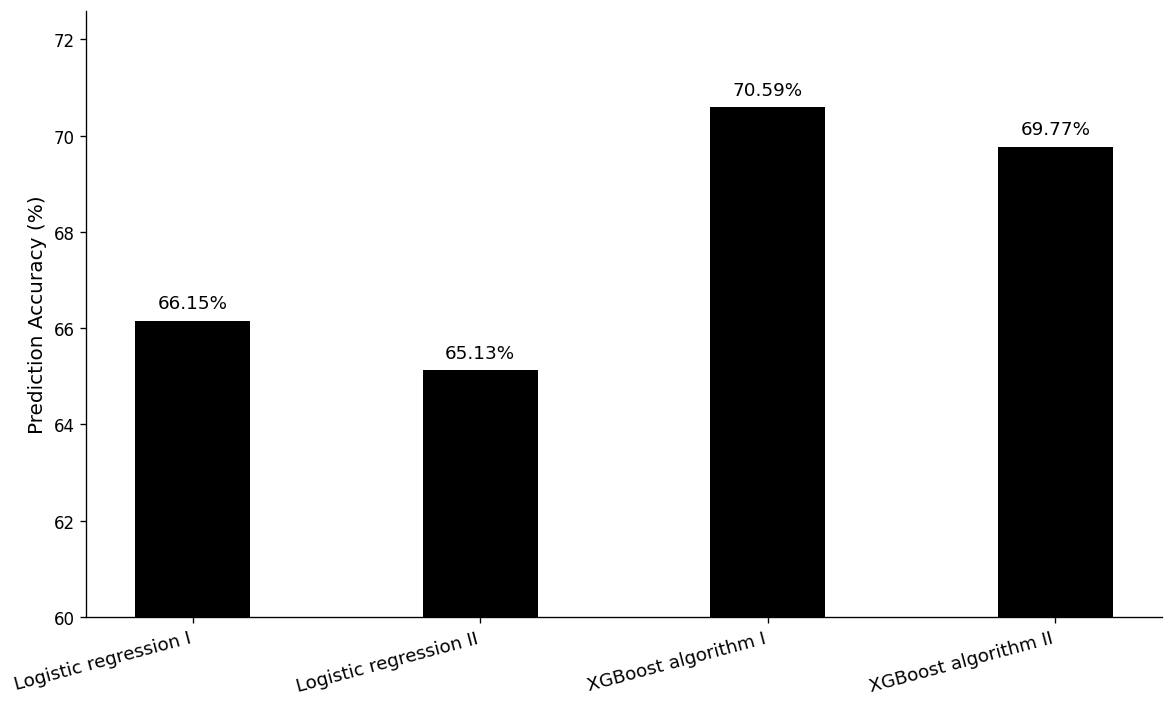

In [8]:
# ====================================================================
# 4. Data Frame Construction & Prediction Accuracy
# ====================================================================

threscut = 0
set_iterations = 1000

# IDEAL
results_ideal = get_ideal_results(test_data)

raw_ideal_metrics = calculate_metrics(results_ideal, results_ideal)
final_df_ideal = raw_ideal_metrics.iloc[[0]].copy()
final_df_ideal.index = ['Ideal (Upper Bound)']

# XGBOOST
demos_probs = get_group_probabilities(trained_models, test_data, "Demos")
all_probs = get_group_probabilities(trained_models, test_data, "All")

results_xgb_demos = get_processed_results(demos_probs, test_data, threshold = threscut)
results_xgb_all = get_processed_results(all_probs, test_data, threshold = threscut)

final_df_xgb = calculate_metrics(results_xgb_demos, results_xgb_all)

# ECONOMETRIC

r_script_path = r"D:\RUC\B1WTA_new\TEST\4.2.1.R"
r_executable = r"D:\R-4.5.2\bin\Rscript.exe" 

print(f"🚀 正在自动调用 R 引擎运行脚本...")

try:
    # 修复编码：指定 encoding='utf-8' 并忽略非法字符
    process = subprocess.run(
        [r_executable, r_script_path], 
        capture_output=True, 
        text=True, 
        check=True, 
        encoding='utf-8', 
        errors='ignore'
    )
    print("✅ R 运行成功！")
except subprocess.CalledProcessError as e:
    print("❌ R 脚本运行出错，请检查 R 代码中的逻辑：")
    print(e.stderr)
    raise

logit_demos = pd.read_csv(os.path.join(r'D:\RUC\B1WTA_new\TEST\empirical4.2_result', 'logit_probs_demos.csv'))
logit_all = pd.read_csv(os.path.join(r'D:\RUC\B1WTA_new\TEST\empirical4.2_result', 'logit_probs_all.csv'))

logit_demos.index = test_data.index
logit_all.index   = test_data.index

results_eco_demos = get_processed_results(logit_demos, test_data, threshold = threscut)
results_eco_all = get_processed_results(logit_all, test_data, threshold = threscut)

final_df_eco = calculate_metrics(results_eco_demos, results_eco_all)

# Monte Carlo Random Baseline
final_df_random = run_monte_carlo_random(test_data, n_iterations=set_iterations)

accuracy_data = {
    'Logistic regression I': clean_pct(final_df_eco.loc["Demos 组", 'Perfect_Rate'])*100,
    'Logistic regression II': clean_pct(final_df_eco.loc["All 组", 'Perfect_Rate'])*100,
    'XGBoost algorithm I': clean_pct(final_df_xgb.loc["Demos 组", 'Perfect_Rate'])*100,
    'XGBoost algorithm II': clean_pct(final_df_xgb.loc["All 组", 'Perfect_Rate'])*100
}

df_acc = pd.Series(accuracy_data)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

x = np.arange(len(df_acc))
width = 0.4  # 柱子宽度

bars = ax.bar(x, df_acc.values, width, color='black')

ax.set_ylim(60, max(accuracy_data['XGBoost algorithm II'],accuracy_data['XGBoost algorithm I'])+2)
ax.set_ylabel('Prediction Accuracy (%)', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(df_acc.index, rotation=15, ha='right', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),  # 向上偏移 5 个点
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11)

save_path_acc = r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\tab7.png"
plt.tight_layout()
plt.savefig(save_path_acc, bbox_inches='tight', dpi=300)

print(f"✅ 预测准确率图表已保存至: {save_path_acc}")
plt.show()

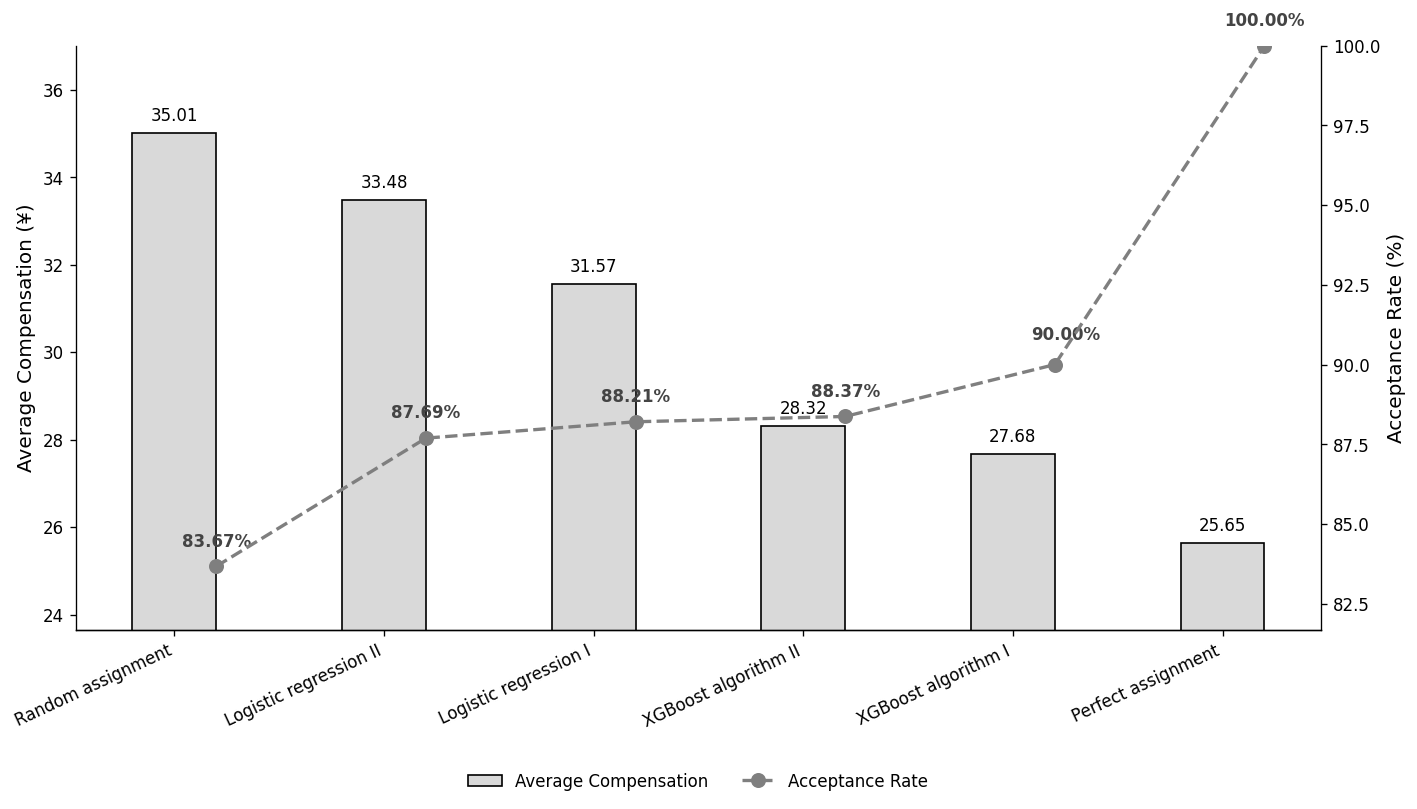

✅ 图表已成功保存


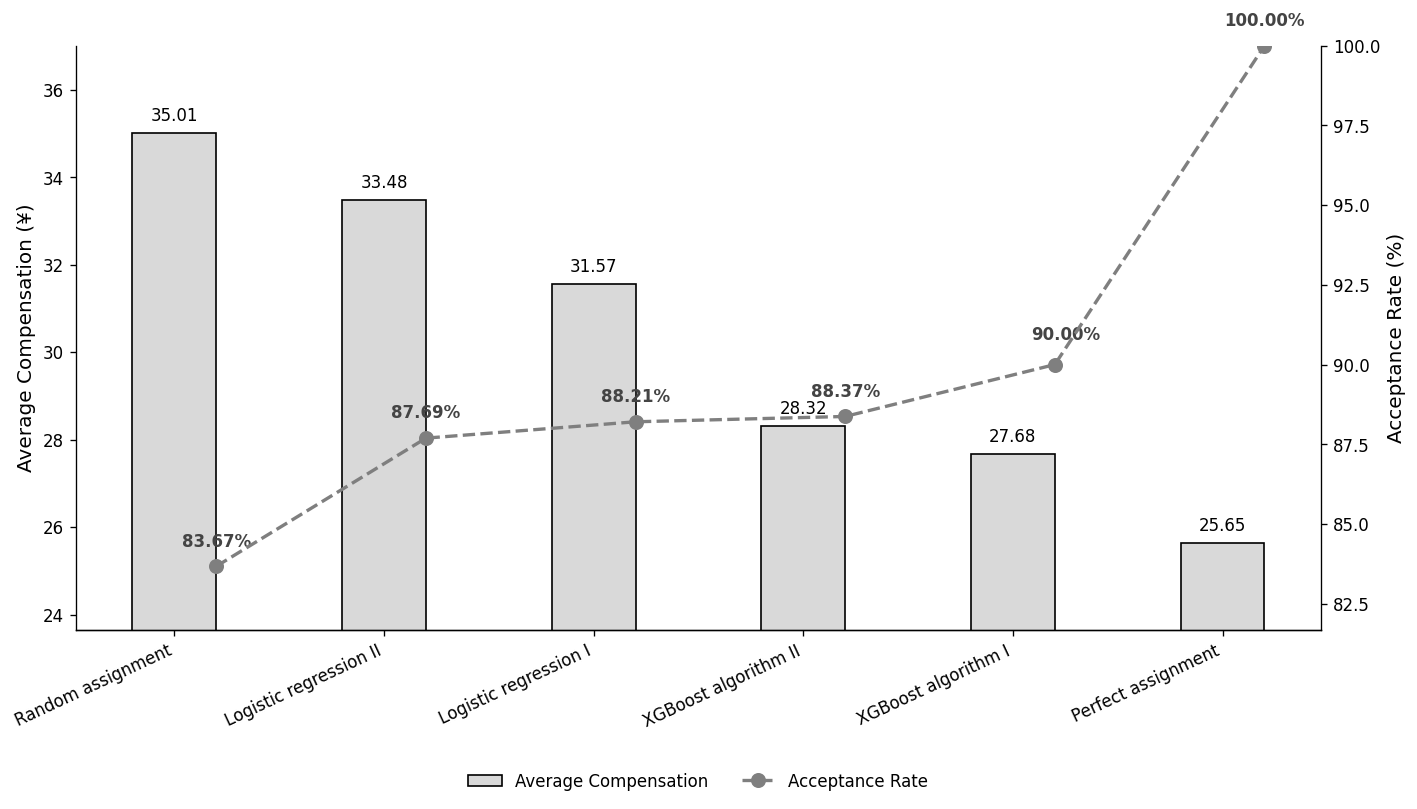

✅ 图表已成功保存


In [63]:
# ====================================================================
# 5. Empirical 4.2.1
# ====================================================================
ordered_keys = ['Random', 'Logit_All', 'Logit_Demos', 'XGB_All', 'XGB_Demos', 'Ideal']
labels = [
    'Random assignment', 
    'Logistic regression II', # 对应 Logit_All
    'Logistic regression I',  # 对应 Logit_Demos
    'XGBoost algorithm II',   # 对应 XGB_All
    'XGBoost algorithm I',    # 对应 XGB_Demos
    'Perfect assignment'
]

raw_data = {
    'Random': {
        'Rate': clean_pct(final_df_random['Accept_Rate'].iloc[0])*100, 
        'Cost': clean_pct(final_df_random['Accept_Cost'].iloc[0])
    },
    'Logit_Demos': {
        'Rate': clean_pct(final_df_eco.loc["Demos 组", 'Accept_Rate'])*100, 
        'Cost': clean_pct(final_df_eco.loc["Demos 组", 'Accept_Cost'])
    },
    'Logit_All': {
        'Rate': clean_pct(final_df_eco.loc["All 组", 'Accept_Rate'])*100, 
        'Cost': clean_pct(final_df_eco.loc["All 组", 'Accept_Cost'])
    },
    'XGB_Demos': {
        'Rate': clean_pct(final_df_xgb.loc["Demos 组", 'Accept_Rate'])*100, 
        'Cost': clean_pct(final_df_xgb.loc["Demos 组", 'Accept_Cost'])
    },
    'XGB_All': {
         'Rate': clean_pct(final_df_xgb.loc["All 组", 'Accept_Rate'])*100, 
        'Cost': clean_pct(final_df_xgb.loc["All 组", 'Accept_Cost'])
    },
    'Ideal': {
        'Rate': clean_pct(final_df_ideal['Accept_Rate'].iloc[0])*100, 
        'Cost': clean_pct(final_df_ideal['Accept_Cost'].iloc[0])
    }
}

# 重新构建用于绘图的 DataFrame
df_plot = pd.DataFrame([raw_data[key] for key in ordered_keys]).apply(pd.to_numeric)

fig, ax1 = plt.subplots(figsize=(12, 7), dpi=120)
ax2 = ax1.twinx() 

x = np.arange(len(labels))
width = 0.4 
x_offset = 0.2 # 偏移量，让点移出柱子正上方

# (A) 左轴：柱状图 (Average Compensation)
bars = ax1.bar(x, df_plot['Cost'], width, color='#d9d9d9', edgecolor='black', label='Average Compensation')

# (B) 右轴：折线图 (Acceptance Rate)
ax2.plot(x + x_offset, df_plot['Rate'], color='#7f7f7f', marker='o', linestyle='--', 
         linewidth=2, markersize=8, label='Acceptance Rate', zorder=5)

# 设置坐标轴范围
ax1.set_ylim(df_plot['Cost'].min()-2, df_plot['Cost'].max()+2)
ax2.set_ylim(df_plot['Rate'].min()-2, 100) 

ax1.set_ylabel('Average Compensation (¥)', fontsize=12)
ax2.set_ylabel('Acceptance Rate (%)', fontsize=12)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=25, ha='right')

# 隐藏边框
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

# 数值标注：柱状图
for i, bar in enumerate(bars):
    ax1.annotate(f"{df_plot['Cost'].iloc[i]:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10)

# 数值标注：折线图 (针对算法 I 和 II 可能的重叠进行优化)
for i in range(len(df_plot)):
    current_y_offset = 12 
    current_x_offset = x_offset
    
    # 对 XGBoost algorithm I (索引为 4) 进行特殊处理，避免标签重叠
    if i == 4:
        current_y_offset = 15 
        current_x_offset += 0.05 

    ax2.annotate(f"{df_plot['Rate'].iloc[i]:.2f}%", 
                 xy=(x[i] + current_x_offset, df_plot['Rate'].iloc[i]), 
                 xytext=(0, current_y_offset), textcoords="offset points",
                 ha='center', fontsize=10, color='#444444', weight='bold')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\tab8.png", bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ 图表已成功保存")

In [28]:


# ====================================================================
# 6. Model Training (WTA): Optuna Bayesian Optimization + Cross Validation
# ====================================================================

trained_models_reg = {}

reg_tasks_reg = [
    {"name": "Car_Demos_Reg",   "train": train_car,   "y": "wta_car",   "features": demos_car,       "type": "Demos"},
    {"name": "Car_All_Reg",     "train": train_car,   "y": "wta_car",   "features": demos_all_car,   "type": "All"},
    {"name": "Elec_Demos_Reg",  "train": train_elec,  "y": "wta_elec",  "features": demos_elec,      "type": "Demos"},
    {"name": "Elec_All_Reg",    "train": train_elec,  "y": "wta_elec",  "features": demos_all_elec,  "type": "All"},
    {"name": "Green_Demos_Reg", "train": train_green, "y": "wta_green", "features": demos_green,     "type": "Demos"},
    {"name": "Green_All_Reg",   "train": train_green, "y": "wta_green", "features": demos_all_green, "type": "All"},
]

for task in reg_tasks_reg:
    print(f"\nStarting Bayesian regression training: {task['name']}...")
    model = train_xgb_regressor_bayesian(
        task['train'][task['features']],
        task['train'][task['y']],
        group_type=task['type'],
        n_trials=100,
        cv=3
    )
    trained_models_reg[task['name']] = model

    preds = model.predict(test_data[task['features']])
    mae   = np.mean(np.abs(test_data[task['y']] - preds))
    print(f"{task['name']} completed, test set MAE (Mean Absolute Error): {mae:.4f}")

print("\nAll regression models training completed.")

params_list_wta = []
for name, model in trained_models_reg.items():
    p_wta = model.get_params()
    params_list_wta.append({
        "Model":         name,
        "n_estimators":  p_wta.get('n_estimators'),
        "max_depth":     p_wta.get('max_depth'),
        "learning_rate": f"{p_wta.get('learning_rate'):.4f}",
        "reg_lambda":    f"{p_wta.get('reg_lambda'):.4f}",
        "gamma":         f"{p_wta.get('gamma'):.4f}",
    })


df_params_wta = pd.DataFrame(params_list_wta).set_index("Model")
df_params_wta


Starting Bayesian regression training: Car_Demos_Reg...
Car_Demos_Reg completed, test set MAE (Mean Absolute Error): 1.7628

Starting Bayesian regression training: Car_All_Reg...
Car_All_Reg completed, test set MAE (Mean Absolute Error): 1.7860

Starting Bayesian regression training: Elec_Demos_Reg...
Elec_Demos_Reg completed, test set MAE (Mean Absolute Error): 1.7361

Starting Bayesian regression training: Elec_All_Reg...
Elec_All_Reg completed, test set MAE (Mean Absolute Error): 1.7369

Starting Bayesian regression training: Green_Demos_Reg...
Green_Demos_Reg completed, test set MAE (Mean Absolute Error): 1.7870

Starting Bayesian regression training: Green_All_Reg...
Green_All_Reg completed, test set MAE (Mean Absolute Error): 1.8119

All regression models training completed.


,n_estimators,max_depth,learning_rate,reg_lambda,gamma
Model,,,,,
Car_Demos_Reg,370,6,0.0588,3.7761,1.8369
Car_All_Reg,410,3,0.0384,1.8461,0.9894
Elec_Demos_Reg,270,4,0.0797,4.6792,1.7463
Elec_All_Reg,330,3,0.0831,3.9497,0.8183
Green_Demos_Reg,110,7,0.0154,4.6530,1.1879
Green_All_Reg,130,3,0.0312,4.7245,0.1470


In [6]:
# ====================================================================
# 6. 模型训练（WTA）：Optuna 贝叶斯优化 + 交叉验证
# ====================================================================

trained_models_reg = {} 

reg_tasks_reg = [
    {"name": "Car_Demos_Reg",   "train": train_car,   "y": "wta_car",   "features": demos_car,      "type": "Demos"},
    {"name": "Car_All_Reg",     "train": train_car,   "y": "wta_car",   "features": demos_all_car,  "type": "All"},
    {"name": "Elec_Demos_Reg",  "train": train_elec,  "y": "wta_elec",  "features": demos_elec,     "type": "Demos"},
    {"name": "Elec_All_Reg",    "train": train_elec,  "y": "wta_elec",  "features": demos_all_elec, "type": "All"},
    {"name": "Green_Demos_Reg", "train": train_green, "y": "wta_green", "features": demos_green,    "type": "Demos"},
    {"name": "Green_All_Reg",   "train": train_green, "y": "wta_green", "features": demos_all_green, "type": "All"},
]

for task in reg_tasks_reg:
    print(f"\n🚀 开始贝叶斯回归训练: {task['name']}...")
    model = train_xgb_regressor_bayesian(
        task['train'][task['features']], 
        task['train'][task['y']], 
        group_type=task['type'],
        n_trials=100, 
        cv=3
    )
    trained_models_reg[task['name']] = model
    
    # 评估回归精度 (MAE)
    preds = model.predict(test_data[task['features']])
    mae = np.mean(np.abs(test_data[task['y']] - preds))
    print(f"✅ {task['name']} 完成，测试集 MAE (平均绝对误差): {mae:.4f}")

print("\n✅ 所有回归模型训练完成。")

params_list_wta = []
for name, model in trained_models_reg.items():
    p_wta = model.get_params()
    params_list_wta.append({
        "Model": name,
        "n_estimators": p_wta.get('n_estimators'),
        "max_depth": p_wta.get('max_depth'),
        "learning_rate": f"{p_wta.get('learning_rate'):.4f}",
        "reg_lambda": f"{p_wta.get('reg_lambda'):.4f}",
        "gamma": f"{p_wta.get('gamma'):.4f}"
    })
df_params_wta = pd.DataFrame(params_list_wta).set_index("Model")
df_params_wta


🚀 开始贝叶斯回归训练: Car_Demos_Reg...
✅ Car_Demos_Reg 完成，测试集 MAE (平均绝对误差): 1.7764

🚀 开始贝叶斯回归训练: Car_All_Reg...
✅ Car_All_Reg 完成，测试集 MAE (平均绝对误差): 1.7736

🚀 开始贝叶斯回归训练: Elec_Demos_Reg...
✅ Elec_Demos_Reg 完成，测试集 MAE (平均绝对误差): 1.7504

🚀 开始贝叶斯回归训练: Elec_All_Reg...
✅ Elec_All_Reg 完成，测试集 MAE (平均绝对误差): 1.7434

🚀 开始贝叶斯回归训练: Green_Demos_Reg...
✅ Green_Demos_Reg 完成，测试集 MAE (平均绝对误差): 1.7572

🚀 开始贝叶斯回归训练: Green_All_Reg...
✅ Green_All_Reg 完成，测试集 MAE (平均绝对误差): 1.7983

✅ 所有回归模型训练完成。


,n_estimators,max_depth,learning_rate,reg_lambda,gamma
Model,,,,,
Car_Demos_Reg,470,6,0.0196,3.8366,1.5951
Car_All_Reg,230,4,0.0752,4.0342,0.5066
Elec_Demos_Reg,230,4,0.0802,4.4908,1.7811
Elec_All_Reg,90,3,0.0888,3.7651,0.9292
Green_Demos_Reg,110,7,0.0993,4.9433,1.1982
Green_All_Reg,270,3,0.0966,4.6937,1.9233


✅ 已根据决策提取对应的预测 WTA (向下取整)。
📊 机器学习模型 (XGB) 结果处理完成，对应df已更新。
🚀 正在运行 R 经济模型 (Ordered Logit)...
✅ R 脚本运行成功！
✅ 已根据决策提取对应的预测 WTA (向下取整)。
📊 经济模型 (Eco) 结果处理完成，对应df已更新。
🔄 正在进行 1000 次蒙特卡洛随机模拟...

📊 政策模拟对比结果 (配额 N = [30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170])


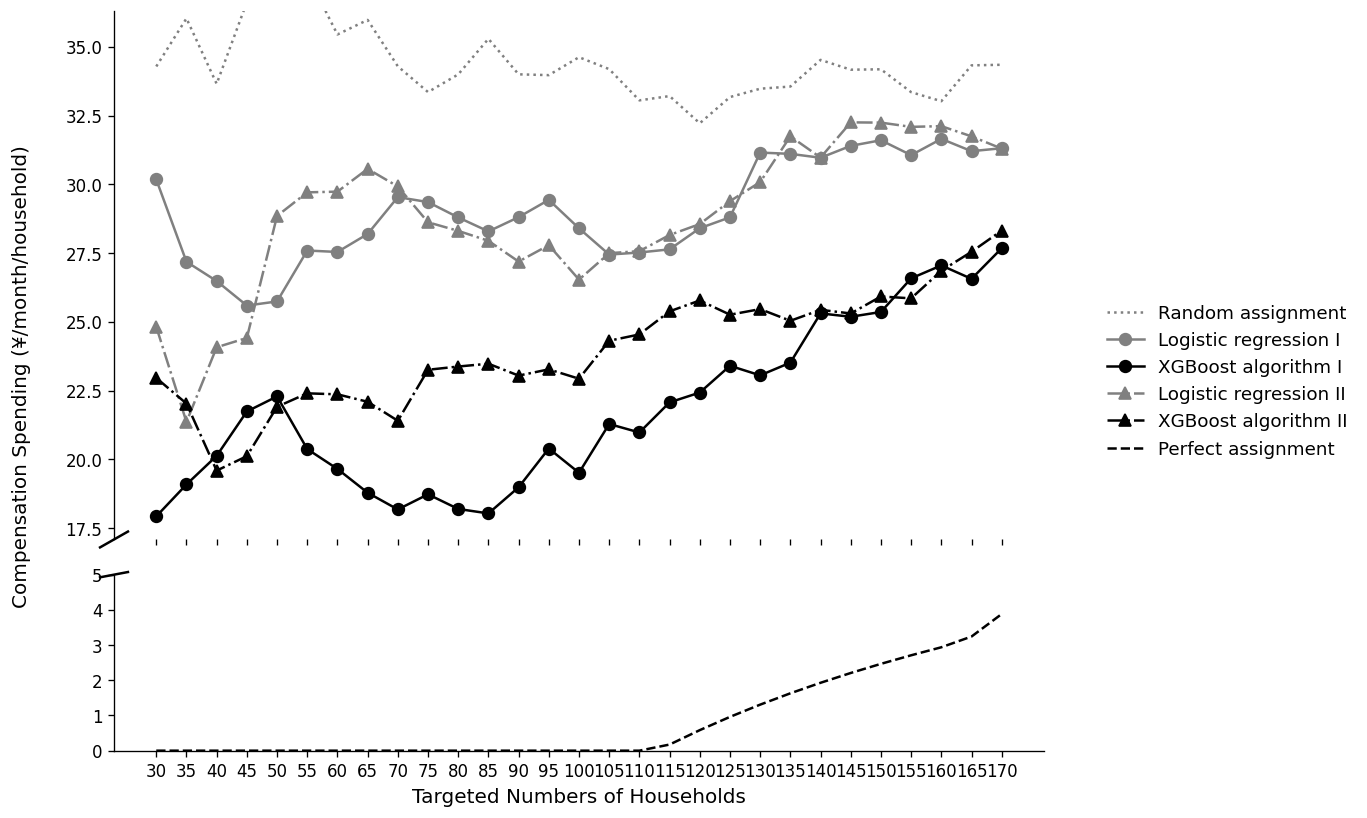

In [ ]:
# ====================================================================
# 7. 更新决策表格（加入pred wta）
# ====================================================================

# XGB
results_xgb_all = append_final_wta_column(results_xgb_all, test_data, trained_models_reg, "All")
results_xgb_demos = append_final_wta_column(results_xgb_demos, test_data, trained_models_reg, "Demos")
print("✅ 已根据决策提取对应的预测 WTA (向下取整)。")
print("📊 机器学习模型 (XGB) 结果处理完成，对应df已更新。")

# XGB
results_xgb_all = append_final_wta_column(results_xgb_all, test_data, trained_models_reg, "All")
results_xgb_demos = append_final_wta_column(results_xgb_demos, test_data, trained_models_reg, "Demos")

# ECO
r_script_path = r"D:\RUC\B1WTA_new\TEST\4.2.2.R"
print("🚀 正在运行 R 经济模型 (Ordered Logit)...")
try:
    # 关键修改：增加 encoding='utf-8' 和 errors='ignore'
    result = subprocess.run(
        [r_executable, r_script_path], 
        capture_output=True, 
        text=True, 
        check=True, 
        encoding='utf-8', 
        errors='ignore'
    )
    print("✅ R 脚本运行成功！")
    # 如果你想看 R 的打印结果，可以解除下面这行的注释
    # print(result.stdout)
    
except subprocess.CalledProcessError as e:
    # 同样对错误输出进行解码处理
    print(f"❌ R 脚本运行失败！错误信息：\n{e.stderr}")
except Exception as e:
    print(f"⚠️ 发生其他错误：{e}")

results_eco_all = update_eco_results_with_floor(results_eco_all, r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\wta_preds_all.csv")
results_eco_demos = update_eco_results_with_floor(results_eco_demos, r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\wta_preds_demos.csv")
print("✅ 已根据决策提取对应的预测 WTA (向下取整)。")
print("📊 经济模型 (Eco) 结果处理完成，对应df已更新。")

# ====================================================================
# 8. Empirical 4.2.2 指定户数的结果
# ====================================================================
current_n_list =  [55, 100, 145]

m_ideal     = get_n_household_metrics(results_ideal, test_data, n_list=current_n_list)
m_xgb_all   = get_n_household_metrics(results_xgb_all, test_data, n_list=current_n_list)
m_xgb_demos = get_n_household_metrics(results_xgb_demos, test_data, n_list=current_n_list)
m_eco_all   = get_n_household_metrics(results_eco_all, test_data, n_list=current_n_list)
m_eco_demos = get_n_household_metrics(results_eco_demos, test_data, n_list=current_n_list)
m_random    = get_random_baseline_monte_carlo(test_data, n_list=current_n_list, iterations=set_iterations)

m_ideal['Group']     = '1. Ideal (Upper Bound)'
m_xgb_all['Group']   = '2.1 XGBoost (All)'
m_xgb_demos['Group'] = '2.2 XGBoost (Demos)'
m_eco_all['Group']   = '3.1 Ordered Logit (All)'
m_eco_demos['Group'] = '3.2 Ordered Logit (Demos)'
m_random['Group']    = '4. Random (1000x Mean)'

all_metrics = pd.concat([m_ideal, m_xgb_all, m_xgb_demos, m_eco_all, m_eco_demos, m_random])

final_pivot = all_metrics.pivot(index='Group', columns='Quota (N)')

auto_format_dict = {}
for col in final_pivot.columns:
    metric_name, n_val = col
    if "Accept_Rate" in metric_name:
        auto_format_dict[col] = "{:.2%}"
    elif "Accept_Cost" in metric_name:
        auto_format_dict[col] = "{:.2f} 元"

print(f"\n📊 政策模拟对比结果 (配额 N = {current_n_list})")
styled_table = final_pivot.style.format(auto_format_dict)

# display(styled_table)

cost_data = final_pivot.xs('Accept_Cost', axis=1)
quota_n = cost_data.columns.tolist()

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(10, 8), 
                                         gridspec_kw={'height_ratios': [3, 1]}, dpi=120)
fig.subplots_adjust(hspace=0.1) 

styles = {
    '4. Random (1000x Mean)':    {'color': 'gray',  'linestyle': ':',  'marker': '',  'label': 'Random assignment'},
    '3.2 Ordered Logit (Demos)': {'color': 'gray',  'linestyle': '-',  'marker': 'o', 'label': 'Logistic regression I'},
    '2.2 XGBoost (Demos)':      {'color': 'black', 'linestyle': '-',  'marker': 'o', 'label': 'XGBoost algorithm I'},
    '3.1 Ordered Logit (All)':   {'color': 'gray',  'linestyle': '-.', 'marker': '^', 'label': 'Logistic regression II'},
    '2.1 XGBoost (All)':        {'color': 'black', 'linestyle': '-.', 'marker': '^', 'label': 'XGBoost algorithm II'},
    '1. Ideal (Upper Bound)':    {'color': 'black', 'linestyle': '--', 'marker': '',  'label': 'Perfect assignment'}
}

for group_name, style in styles.items():
    if group_name in cost_data.index:
        y_values = cost_data.loc[group_name].values
        ax_top.plot(quota_n, y_values, **style, linewidth=1.5, markersize=7)
        ax_bottom.plot(quota_n, y_values, **style, linewidth=1.5, markersize=7)

ax_top.set_ylim(min(m_xgb_demos.loc[1]['Accept_Cost'],m_xgb_all.loc[0]['Accept_Cost'])-2, m_random.loc[0]['Accept_Cost']+2)
ax_bottom.set_ylim(0, m_ideal.loc[0]['Accept_Cost']+5)

ax_top.spines['bottom'].set_visible(False)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_bottom.spines['right'].set_visible(False)

ax_top.tick_params(labeltop=False) 
ax_bottom.xaxis.tick_bottom()

d = .015
kwargs = dict(transform=ax_top.transAxes, color='black', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)  
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)

fig.text(0.04, 0.5, 'Compensation Spending (¥/month/household)', 
         va='center', rotation='vertical', fontsize=12)
ax_bottom.set_xlabel('Targeted Numbers of Households', fontsize=12)
ax_bottom.set_xticks(quota_n)

ax_top.legend(loc='center left', 
              bbox_to_anchor=(1.05, 0.3), 
              frameon=False, 
              fontsize=11)

save_path_line = r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\tab9.png"
plt.savefig(save_path_line, bbox_inches='tight', dpi=300)
plt.show()

✅ 已根据决策提取对应的预测 WTA (向下取整)。
📊 机器学习模型 (XGB) 结果处理完成，对应df已更新。
🚀 正在运行 R 经济模型 (Ordered Logit)...
✅ R 脚本运行成功！
✅ 已根据决策提取对应的预测 WTA (向下取整)。
📊 经济模型 (Eco) 结果处理完成，对应df已更新。
🔄 正在进行 1000 次蒙特卡洛随机模拟...

📊 政策模拟对比结果 (配额 N = [55, 100, 145])


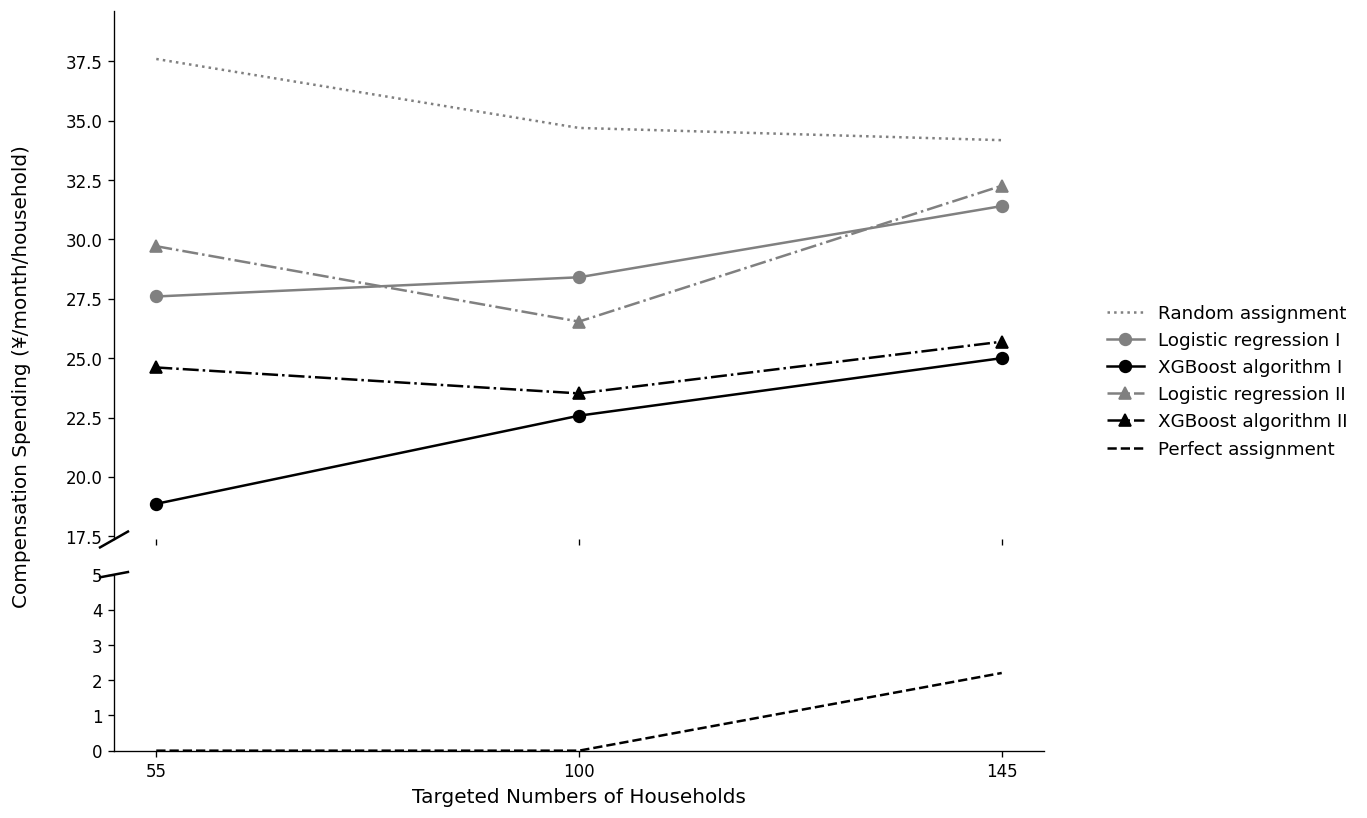

✅ 已根据决策提取对应的预测 WTA (向下取整)。
📊 机器学习模型 (XGB) 结果处理完成，对应df已更新。
🚀 正在运行 R 经济模型 (Ordered Logit)...
✅ R 脚本运行成功！
✅ 已根据决策提取对应的预测 WTA (向下取整)。
📊 经济模型 (Eco) 结果处理完成，对应df已更新。
🔄 正在进行 1000 次蒙特卡洛随机模拟...

📊 政策模拟对比结果 (配额 N = [55, 100, 145])


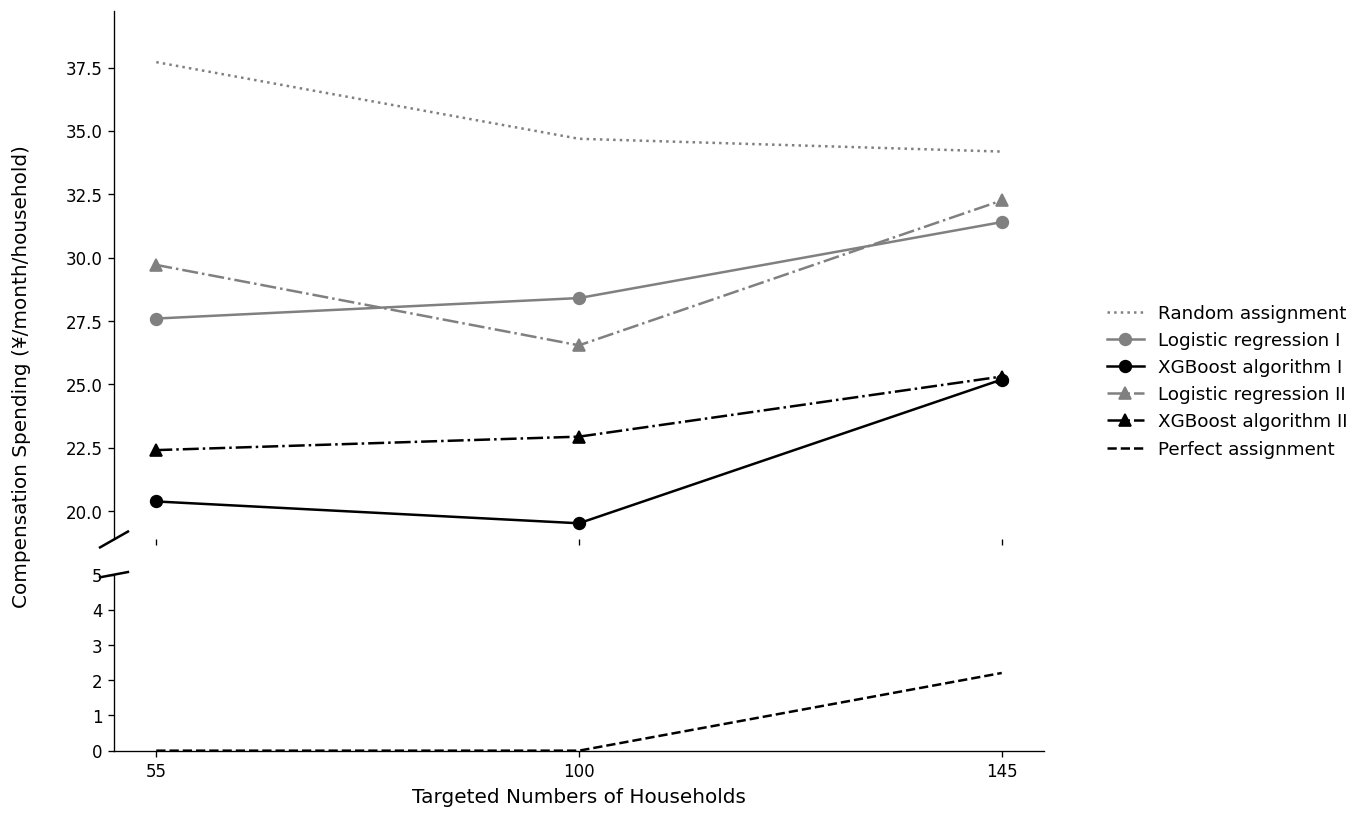

In [60]:
# ====================================================================
# 7. 更新决策表格（加入pred wta）
# ====================================================================

# XGB
results_xgb_all = append_final_wta_column(results_xgb_all, test_data, trained_models_reg, "All")
results_xgb_demos = append_final_wta_column(results_xgb_demos, test_data, trained_models_reg, "Demos")
print("✅ 已根据决策提取对应的预测 WTA (向下取整)。")
print("📊 机器学习模型 (XGB) 结果处理完成，对应df已更新。")

# XGB
results_xgb_all = append_final_wta_column(results_xgb_all, test_data, trained_models_reg, "All")
results_xgb_demos = append_final_wta_column(results_xgb_demos, test_data, trained_models_reg, "Demos")

# ECO
r_script_path = r"D:\RUC\B1WTA_new\TEST\4.2.2.R"
print("🚀 正在运行 R 经济模型 (Ordered Logit)...")
try:
    # 关键修改：增加 encoding='utf-8' 和 errors='ignore'
    result = subprocess.run(
        [r_executable, r_script_path], 
        capture_output=True, 
        text=True, 
        check=True, 
        encoding='utf-8', 
        errors='ignore'
    )
    print("✅ R 脚本运行成功！")
    # 如果你想看 R 的打印结果，可以解除下面这行的注释
    # print(result.stdout)
    
except subprocess.CalledProcessError as e:
    # 同样对错误输出进行解码处理
    print(f"❌ R 脚本运行失败！错误信息：\n{e.stderr}")
except Exception as e:
    print(f"⚠️ 发生其他错误：{e}")

results_eco_all = update_eco_results_with_floor(results_eco_all, r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\wta_preds_all.csv")
results_eco_demos = update_eco_results_with_floor(results_eco_demos, r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\wta_preds_demos.csv")
print("✅ 已根据决策提取对应的预测 WTA (向下取整)。")
print("📊 经济模型 (Eco) 结果处理完成，对应df已更新。")

# ====================================================================
# 8. Empirical 4.2.2 指定户数的结果
# ====================================================================
current_n_list =  [70, 120, 170]
current_n_list =  [60, 115, 170]
current_n_list =  [55, 110, 165]
current_n_list = [55, 100, 145]

m_ideal     = get_n_household_metrics(results_ideal, test_data, n_list=current_n_list)
m_xgb_all   = get_n_household_metrics(results_xgb_all, test_data, n_list=current_n_list)
m_xgb_demos = get_n_household_metrics(results_xgb_demos, test_data, n_list=current_n_list)
m_eco_all   = get_n_household_metrics(results_eco_all, test_data, n_list=current_n_list)
m_eco_demos = get_n_household_metrics(results_eco_demos, test_data, n_list=current_n_list)
m_random    = get_random_baseline_monte_carlo(test_data, n_list=current_n_list, iterations=set_iterations)


m_ideal['Group']     = '1. Ideal (Upper Bound)'
m_xgb_all['Group']   = '2.1 XGBoost (All)'
m_xgb_demos['Group'] = '2.2 XGBoost (Demos)'
m_eco_all['Group']   = '3.1 Ordered Logit (All)'
m_eco_demos['Group'] = '3.2 Ordered Logit (Demos)'
m_random['Group']    = '4. Random (1000x Mean)'

all_metrics = pd.concat([m_ideal, m_xgb_all, m_xgb_demos, m_eco_all, m_eco_demos, m_random])

final_pivot = all_metrics.pivot(index='Group', columns='Quota (N)')

auto_format_dict = {}
for col in final_pivot.columns:
    metric_name, n_val = col
    if "Accept_Rate" in metric_name:
        auto_format_dict[col] = "{:.2%}"
    elif "Accept_Cost" in metric_name:
        auto_format_dict[col] = "{:.2f} 元"

print(f"\n📊 政策模拟对比结果 (配额 N = {current_n_list})")
styled_table = final_pivot.style.format(auto_format_dict)

# display(styled_table)

cost_data = final_pivot.xs('Accept_Cost', axis=1)
quota_n = cost_data.columns.tolist()

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(10, 8), 
                                         gridspec_kw={'height_ratios': [3, 1]}, dpi=120)
fig.subplots_adjust(hspace=0.1) 

styles = {
    '4. Random (1000x Mean)':    {'color': 'gray',  'linestyle': ':',  'marker': '',  'label': 'Random assignment'},
    '3.2 Ordered Logit (Demos)': {'color': 'gray',  'linestyle': '-',  'marker': 'o', 'label': 'Logistic regression I'},
    '2.2 XGBoost (Demos)':      {'color': 'black', 'linestyle': '-',  'marker': 'o', 'label': 'XGBoost algorithm I'},
    '3.1 Ordered Logit (All)':   {'color': 'gray',  'linestyle': '-.', 'marker': '^', 'label': 'Logistic regression II'},
    '2.1 XGBoost (All)':        {'color': 'black', 'linestyle': '-.', 'marker': '^', 'label': 'XGBoost algorithm II'},
    '1. Ideal (Upper Bound)':    {'color': 'black', 'linestyle': '--', 'marker': '',  'label': 'Perfect assignment'}
}

for group_name, style in styles.items():
    if group_name in cost_data.index:
        y_values = cost_data.loc[group_name].values
        ax_top.plot(quota_n, y_values, **style, linewidth=1.5, markersize=7)
        ax_bottom.plot(quota_n, y_values, **style, linewidth=1.5, markersize=7)

ax_top.set_ylim(min(m_xgb_demos.loc[0]['Accept_Cost'],m_xgb_all.loc[0]['Accept_Cost'])-1.5, m_random.loc[0]['Accept_Cost']+2)
ax_bottom.set_ylim(0, m_ideal.loc[0]['Accept_Cost']+5)

ax_top.spines['bottom'].set_visible(False)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_bottom.spines['right'].set_visible(False)

ax_top.tick_params(labeltop=False) 
ax_bottom.xaxis.tick_bottom()

d = .015
kwargs = dict(transform=ax_top.transAxes, color='black', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)  
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)

fig.text(0.04, 0.5, 'Compensation Spending (¥/month/household)', 
         va='center', rotation='vertical', fontsize=12)
ax_bottom.set_xlabel('Targeted Numbers of Households', fontsize=12)
ax_bottom.set_xticks(quota_n)

ax_top.legend(loc='center left', 
              bbox_to_anchor=(1.05, 0.3), 
              frameon=False, 
              fontsize=11)

save_path_line = r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\tab9.png"
plt.savefig(save_path_line, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
display(styled_table)

🔄 正在进行 1000 次预算约束下的蒙特卡洛随机模拟...


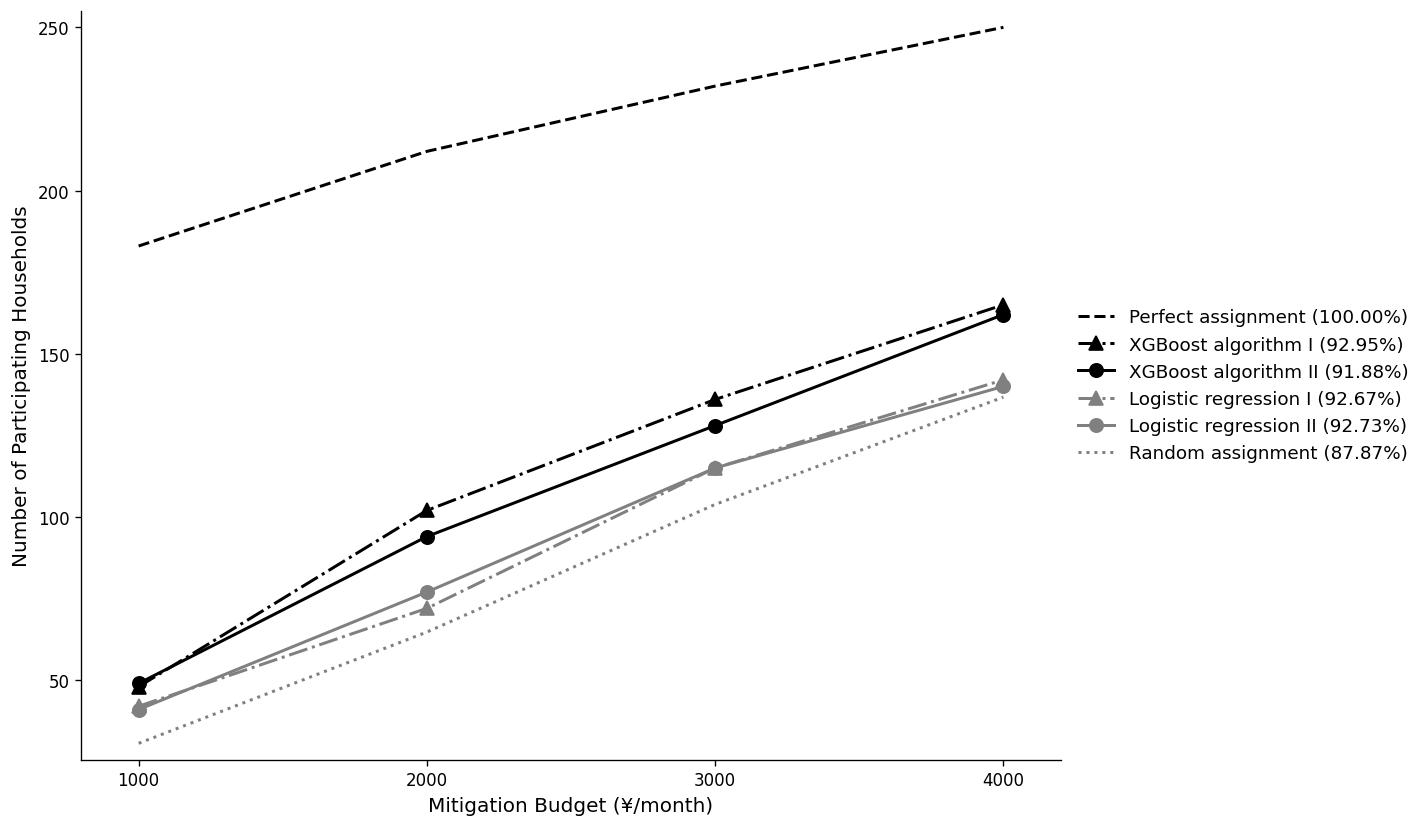

In [11]:
# ====================================================================
# 9. Empirical 4.2.3 有限成本的结果
# ====================================================================

current_budgets = [1000, 2000, 3000, 4000]

bm_ideal      = get_budget_metrics(results_ideal, test_data, budget_list=current_budgets)
bm_xgb_all    = get_budget_metrics(results_xgb_all, test_data, budget_list=current_budgets)
bm_xgb_demos  = get_budget_metrics(results_xgb_demos, test_data, budget_list=current_budgets)
bm_eco_all    = get_budget_metrics(results_eco_all, test_data, budget_list=current_budgets)
bm_eco_demos  = get_budget_metrics(results_eco_demos, test_data, budget_list=current_budgets)
bm_random     = get_random_budget_baseline_monte_carlo(test_data, current_budgets, iterations=set_iterations)

bm_ideal['Group']      = '1. Ideal (Theoretical Max)'
bm_xgb_all['Group']    = '2.1 XGBoost (All Features)'
bm_xgb_demos['Group']  = '2.2 XGBoost (Demos Only)'
bm_eco_all['Group']    = '3.1 Ordered Logit (All Features)'
bm_eco_demos['Group']  = '3.2 Ordered Logit (Demos Only)'
bm_random['Group']     = '4. Random (1000x Mean)'

budget_final = pd.concat([
    bm_ideal, 
    bm_xgb_all, bm_xgb_demos, 
    bm_eco_all, bm_eco_demos, 
    bm_random
])

budget_pivot = budget_final.pivot(index='Group', columns='Budget_Limit')

budget_pivot[('Accept_Rate', 'Average')] = budget_pivot['Accept_Rate'].mean(axis=1)

b_format_dict = {}
for col in budget_pivot.columns:
    if "Accept_Rate" in col[0]:
        b_format_dict[col] = "{:.2%}"
    else:
        b_format_dict[col] = "{:.1f} 户"

display(budget_pivot.style.format(b_format_dict))

plot_df = budget_pivot['Total_Recruited (N)']
current_budgets = plot_df.columns.tolist() 

avg_rates = budget_pivot[('Accept_Rate', 'Average')]

fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

styles = {
    '1. Ideal (Theoretical Max)':      {'color': 'black', 'linestyle': '--', 'marker': '',  'label_base': 'Perfect assignment'},
    '2.2 XGBoost (Demos Only)':       {'color': 'black', 'linestyle': '-.',  'marker': '^', 'label_base': 'XGBoost algorithm I'},
    '2.1 XGBoost (All Features)':     {'color': 'black', 'linestyle': '-',  'marker': 'o', 'label_base': 'XGBoost algorithm II'},
    '3.2 Ordered Logit (Demos Only)':  {'color': 'gray',  'linestyle': '-.',  'marker': '^', 'label_base': 'Logistic regression I'},
    '3.1 Ordered Logit (All Features)':{'color': 'gray',  'linestyle': '-',  'marker': 'o', 'label_base': 'Logistic regression II'},
    '4. Random (1000x Mean)':          {'color': 'gray',  'linestyle': ':',  'marker': '',  'label_base': 'Random assignment'}
}

for group_name, style in styles.items():
    if group_name in plot_df.index:
        y_values = plot_df.loc[group_name].values
        rate_val = avg_rates.loc[group_name]
        full_label = f"{style['label_base']} ({rate_val:.2%})" if isinstance(rate_val, float) else f"{style['label_base']} ({rate_val})"
        
        ax.plot(current_budgets, y_values, 
                color=style['color'], 
                linestyle=style['linestyle'], 
                marker=style['marker'], 
                label=full_label,
                linewidth=1.8, markersize=8)

ax.set_xlabel('Mitigation Budget (¥/month)', fontsize=12)
ax.set_ylabel('Number of Participating Households', fontsize=12)

ax.set_xticks(current_budgets)
ax.set_xlim(min(current_budgets)-200, max(current_budgets)+200)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(plot_df.min().min()-5, plot_df.max().max()+5)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig(r"D:\RUC\B1WTA_new\TEST\empirical4.2_result\tab10.png", bbox_inches='tight', dpi=300)

plt.show()

In [65]:
# ====================================================================
# 10. Empirical 4.3 模拟-知识增长
# ====================================================================
threscut = 0
n_iterations = 200
all_iteration_results = []
required_cols = [
        'know_about_carbon_policy_never', 'know_about_carbon_policy_heard but do not know',
    'know_about_carbon_neutrality_heard but do not know', 'know_about_carbon_neutrality_never'
    ]
test_base = test_data_eco.copy().reset_index(drop=True)
r_script_path_sm = r"D:\RUC\B1WTA_new\TEST\4.3.R"

print(f"🚀 开始执行 {n_iterations} 次知识增长模拟...")

simulate4_3_results = {
    'ideal_sm': {},
    'random_sm': {},
    'xgb_all_sm': {},
    'xgb_demos_sm': {},
    'eco_all_sm': {},
    'eco_demos_sm': {}
}

check_results = {
    'wta_car':[],
    'wta_elec':[],
    'wta_green':[],
}

for i in tqdm(range(n_iterations)):
    np.random.seed(RANDOM_SEED + i)
    # --- ① 更新Test_data (WTA + 认知提升) ---
    simulated_tb = simulate_policy_knowledge_upgrade(test_base.copy())
    check_results['wta_car'].append(simulated_tb['wta_car'].mean())
    check_results['wta_elec'].append(simulated_tb['wta_elec'].mean())
    check_results['wta_green'].append(simulated_tb['wta_green'].mean())

    # --- ② ECO 部分 (需要通过 R 脚本获取新预测) ---
    simulated_tb.to_csv(f"D:/RUC/B1WTA_new/TEST/empirical4.2_result/test_data_simulated.csv", index=False, encoding='utf-8-sig')

    try:
        process = subprocess.run(
            [r_executable, r_script_path_sm], 
            capture_output=True, 
            text=True, 
            check=True, 
            encoding='utf-8', 
            errors='ignore'
        )
    except subprocess.CalledProcessError as e:
        print("❌ R 脚本运行出错，请检查 R 代码中的逻辑：")
        print(e.stderr)
        raise
        
    logit_demos_sm = pd.read_csv(os.path.join(r'D:\RUC\B1WTA_new\TEST\empirical4.3_result', 'logit_probs_demos_simulated.csv'))
    logit_all_sm = pd.read_csv(os.path.join(r'D:\RUC\B1WTA_new\TEST\empirical4.3_result', 'logit_probs_all_simulated.csv'))
    logit_demos_sm.index = simulated_tb.index
    logit_all_sm.index   = simulated_tb.index
    
    results_eco_demos_sm = get_processed_results(logit_demos_sm, simulated_tb, threshold = threscut)
    results_eco_all_sm = get_processed_results(logit_all_sm, simulated_tb, threshold = threscut)
    
    final_df_eco_sm = calculate_metrics(results_eco_demos_sm, results_eco_all_sm)

    # --- ③ Prepare Data Form for Other Situations ---
    simulated_tb = pd.get_dummies(simulated_tb, columns=categorical_cols, drop_first=False)
    simulated_tb = simulated_tb.astype(int, errors='ignore')
    for col in required_cols:
        if col not in simulated_tb.columns:
            simulated_tb[col] = 0

    # --- ④ IDEAL with simulated test_data ---
    results_ideal_sm = get_ideal_results(simulated_tb)
    raw_ideal_metrics_sm = calculate_metrics(results_ideal_sm, results_ideal_sm)
    final_df_ideal_sm = raw_ideal_metrics_sm.iloc[[0]].copy()
    final_df_ideal_sm.index = ['Ideal (Upper Bound)']
    
    # --- ⑤ RANDOM with simulated test_data --- 
    final_df_random_sm = run_monte_carlo_random(simulated_tb, n_iterations=set_iterations)

    # --- ⑥ XGBOOST with simulated test_data --- 
    demos_probs_sm = get_group_probabilities(trained_models, simulated_tb, "Demos")
    all_probs_sm = get_group_probabilities(trained_models, simulated_tb, "All")
    results_xgb_demos_sm = get_processed_results(demos_probs_sm, simulated_tb, threshold = threscut)
    results_xgb_all_sm = get_processed_results(all_probs_sm, simulated_tb, threshold = threscut)
    
    final_df_xgb_sm = calculate_metrics(results_xgb_demos_sm, results_xgb_all_sm)

    # --- ⑦ 数据汇总 --- 
    # 1. Ideal
    append_metrics(simulate4_3_results['ideal_sm'], final_df_ideal_sm, 0)
    
    # 2. Random
    append_metrics(simulate4_3_results['random_sm'], final_df_random_sm, 0)
    
    # 3. XGBoost 系列
    append_metrics(simulate4_3_results['xgb_demos_sm'], final_df_xgb_sm, 0) 
    append_metrics(simulate4_3_results['xgb_all_sm'],   final_df_xgb_sm, 1)
    
    # 4. ECO (Logit) 系列
    append_metrics(simulate4_3_results['eco_demos_sm'], final_df_eco_sm, 0)
    append_metrics(simulate4_3_results['eco_all_sm'],   final_df_eco_sm, 1)



🚀 开始执行 200 次知识增长模拟...


100%|██████████████████████████████████████████████████████████████████████████████| 200/200 [1:51:46<00:00, 33.53s/it]


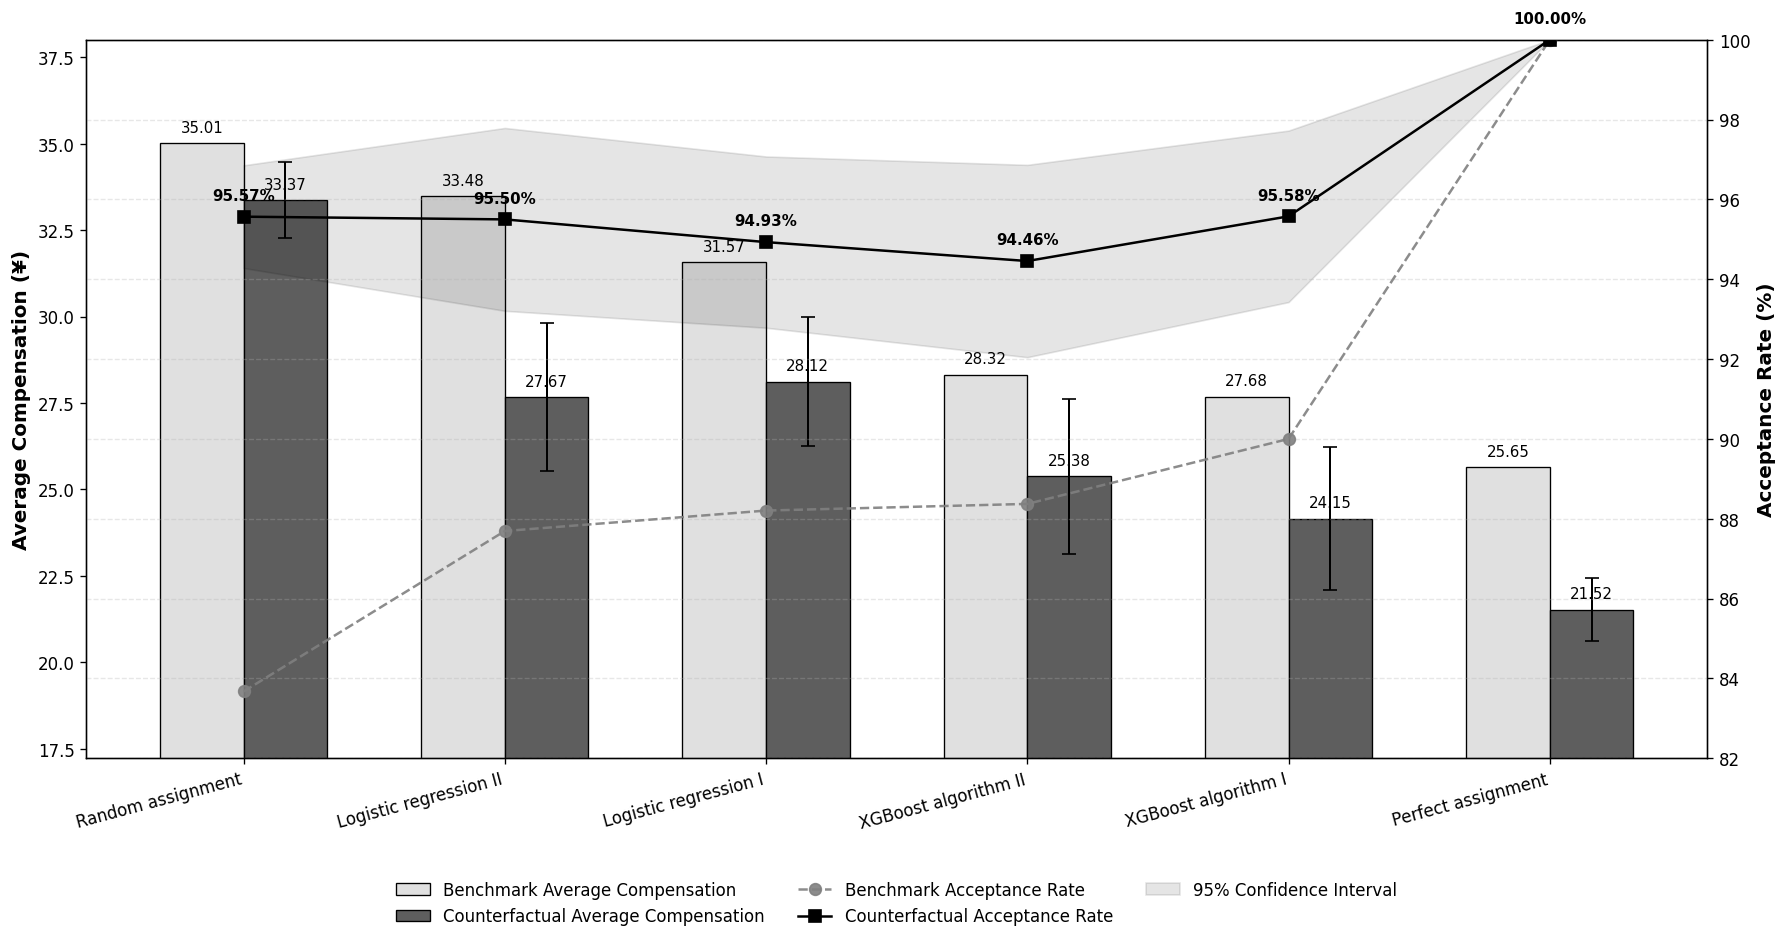

In [72]:

# 计算模拟情况的统计量
summary_stats = []

for scenario, data in simulate4_3_results.items():
    costs = data.get('accept_cost', [])
    rates = data.get('accept_rate', [])
    
    if costs and rates:
        summary_stats.append({
            'Scenario': scenario,
            'Cost_Mean': np.mean(costs),
            'Cost_Std': np.std(costs),
            'Rate_Mean': np.mean(rates),
            'Rate_Std': np.std(rates),
            'Cost_CV': np.std(costs) / np.mean(costs) if np.mean(costs) != 0 else 0
        })

df_summary = pd.DataFrame(summary_stats)

name_map = {
    'ideal_sm': 'Perfect assignment',
    'random_sm': 'Random assignment',
    'xgb_all_sm': 'XGBoost algorithm II',
    'xgb_demos_sm': 'XGBoost algorithm I',
    'eco_all_sm': 'Logistic regression II',
    'eco_demos_sm': 'Logistic regression I'
}
df_summary['Scenario'] = df_summary['Scenario'].map(name_map)

# 计算基准情况的统计量
simulate4_3_results_baseline = {
    'ideal': {},
    'random': {},
    'xgb_all': {},
    'xgb_demos': {},
    'eco_all': {},
    'eco_demos': {}
}

append_metrics(simulate4_3_results_baseline['ideal'], final_df_ideal, 0)
append_metrics(simulate4_3_results_baseline['random'], final_df_random, 0)
append_metrics(simulate4_3_results_baseline['xgb_demos'], final_df_xgb, 0) 
append_metrics(simulate4_3_results_baseline['xgb_all'],   final_df_xgb, 1)
append_metrics(simulate4_3_results_baseline['eco_demos'], final_df_eco, 0)
append_metrics(simulate4_3_results_baseline['eco_all'],   final_df_eco, 1)

baseline_list = []
name_map_baseline = {
    'ideal': 'Perfect assignment',
    'random': 'Random assignment',
    'xgb_all': 'XGBoost algorithm II',
    'xgb_demos': 'XGBoost algorithm I',
    'eco_all': 'Logistic regression II',
    'eco_demos': 'Logistic regression I'
}
for key, val in simulate4_3_results_baseline.items():
    baseline_list.append({
        'Scenario': name_map_baseline[key],
        'B_Cost': val['accept_cost'][0],
        'B_Rate': val['accept_rate'][0]
    })
df_baseline = pd.DataFrame(baseline_list)

# 顺序设定为：Random, Logit1, Logit2, XGBoost1, XGBoost2, Ideal
ordered_scenarios = [
    'Random assignment', 
    'Logistic regression II', 
    'Logistic regression I', 
    'XGBoost algorithm II', 
    'XGBoost algorithm I', 
    'Perfect assignment'
]

# 合并数据
plot_df = pd.merge(df_summary, df_baseline, on='Scenario')

# 强制按照指定顺序排列
plot_df['Scenario'] = pd.Categorical(plot_df['Scenario'], categories=ordered_scenarios, ordered=True)
plot_df = plot_df.sort_values('Scenario').reset_index(drop=True)

# 计算 95% 置信区间 
# 1. 动态获取真实的模拟次数
n_sim = len(simulate4_3_results['ideal_sm']['accept_cost']) 

# 2. 计算 95% 置信区间 (基于真实的 n_sim)
t_val = stats.t.ppf(0.975, n_sim - 1)

# 3. 计算 Cost 和 Rate 的置信区间
# plot_df['Cost_CI'] = t_val * (plot_df['Cost_Std'] / np.sqrt(n_sim))
# plot_df['Rate_CI_Pct'] = t_val * (plot_df['Rate_Std'] / np.sqrt(n_sim)) * 100
plot_df['Cost_CI'] = t_val * (plot_df['Cost_Std'])
plot_df['Rate_CI_Pct'] = t_val * (plot_df['Rate_Std']) * 100

# 转换百分比显示
plot_df['Rate_Mean_Pct'] = plot_df['Rate_Mean'] * 100
plot_df['B_Rate_Pct'] = plot_df['B_Rate'] * 100

fig, ax1 = plt.subplots(figsize=(15, 8), dpi=120)
ax2 = ax1.twinx()

x = np.arange(len(plot_df))
width = 0.32  # 柱状图宽度

# --- A. 柱状图 (左轴：平均补偿金额) ---
# Benchmark (浅灰色)
bar1 = ax1.bar(x - width/2, plot_df['B_Cost'], width, label='Benchmark Average Compensation', 
               color='#E0E0E0', edgecolor='black', linewidth=0.8, zorder=2)
# Counterfactual (深灰色) + 误差棒 (95% CI)
bar2 = ax1.bar(x + width/2, plot_df['Cost_Mean'], width, label='Counterfactual Average Compensation', 
               color='#5E5E5E', edgecolor='black', linewidth=0.8, 
               yerr=plot_df['Cost_CI'], capsize=4, error_kw={'elinewidth':1.2}, zorder=2)

# --- B. 折线图 (右轴：接受率) ---
# Benchmark Rate (灰色虚线 + 圆点)
ax2.plot(x, plot_df['B_Rate_Pct'], color='#808080', linestyle='--', marker='o', 
         markersize=7, label='Benchmark Acceptance Rate', alpha=0.9, zorder=3)
# Counterfactual Rate (黑色实线 + 方块)
ax2.plot(x, plot_df['Rate_Mean_Pct'], color='black', linestyle='-', marker='s', 
         markersize=7, linewidth=1.5, label='Counterfactual Acceptance Rate', zorder=4)
# 95% 置信区间阴影 (Rate)
ax2.fill_between(x, plot_df['Rate_Mean_Pct'] - plot_df['Rate_CI_Pct'], 
                 plot_df['Rate_Mean_Pct'] + plot_df['Rate_CI_Pct'], 
                 color='black', alpha=0.1, label='95% Confidence Interval')

# --- 3. 细节美化与标注 ---
# 轴标签
ax1.set_ylabel('Average Compensation (¥)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Acceptance Rate (%)', fontsize=12, fontweight='bold')

# 坐标轴范围微调 (确保数值标注不被遮挡)
ax1.set_ylim(df_summary.loc[0]['Cost_Mean'] - 4.3, df_baseline.loc[1]['B_Cost']+3)
ax2.set_ylim(82, 100)

# X 轴刻度
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df['Scenario'], rotation=15, ha='right', fontsize=10)

# 在柱子上方添加数值标注 (保留两位小数)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=9)

autolabel(bar1)
autolabel(bar2)

# 在折线上标注百分比 (Counterfactual)
for i, val in enumerate(plot_df['Rate_Mean_Pct']):
    ax2.annotate(f'{val:.2f}%', (x[i], val), xytext=(0, 10), 
                 textcoords="offset points", ha='center', fontsize=9, fontweight='bold')

# 图例位置 (底部居中)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
plt.tight_layout()
save_path_line = r"D:\RUC\B1WTA_new\TEST\empirical4.3_result\tab11.png"
plt.savefig(save_path_line, bbox_inches='tight', dpi=300)
plt.show()


In [67]:

import pickle
import os
save_path = r"D:\RUC\B1WTA_new\TEST\empirical4.3_result\simulate4_3_results.pkl"
# os.makedirs(os.path.dirname(save_path), exist_ok=True)
with open(save_path, 'wb') as f:
    pickle.dump(simulate4_3_results, f)
print(f"✅ 结果已成功保存至: {save_path}")


✅ 结果已成功保存至: D:\RUC\B1WTA_new\TEST\empirical4.3_result\simulate4_3_results.pkl
